# <center> Проект: изучаем финансовые показатели НКО
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

c:\Users\elwut\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# импортируем все необходимые для работы библиотеки

In [2]:
df_moscow = pd.read_excel('data/выборка компаний Москва.xlsx', sheet_name='report')
df_other = pd.read_excel('data/организации кроме Москвы.xlsx', sheet_name='report')

print("Размеры:")
print(f"Москва: {df_moscow.shape}")
print(f"Другие: {df_other.shape}")

# Проверка структуры
cols_match = True
for i, (col1, col2) in enumerate(zip(df_moscow.columns, df_other.columns)):
    if col1 != col2:
        print(f"РАСХОЖДЕНИЕ в столбце {i}: '{col1}' != '{col2}'")
        cols_match = False

if cols_match:
    print("✅ Все столбцы совпадают")
    df = pd.concat([df_moscow, df_other], ignore_index=True)
    print(f"Объединенный датасет: {df.shape}")
    
    # Сохранение в отдельный файл
    df.to_csv('data/merged_data.csv', index=False)
    print("✅ Данные сохранены в data/merged_data.csv")
else:
    print("❌ Структуры различаются")
    df = None

Размеры:
Москва: (3647, 162)
Другие: (7525, 162)
✅ Все столбцы совпадают
Объединенный датасет: (11172, 162)
✅ Данные сохранены в data/merged_data.csv


In [ ]:
# подключаемся к исправленным датасетам (эксель таблицы мусорные, очищаем до исходных необходимых данных)
# сравниваем два файла, если они имеет одинаковую структуру, объединим их в один датасет и сохраним в merged_data.csv

# Юнит 3. Предварительный анализ данных

1. Обработаем данные для удобства анализа

In [3]:
df = pd.read_csv('data/merged_data.csv')
for i, col in enumerate(df.columns[:15]):
    print(f"{i}: {col}")
    print(f"   Примеры: {df[col].dropna().head(3).tolist()}")
    print()

0: №
   Примеры: [1, 2, 3]

1: Наименование
   Примеры: ['101 КИЛОМЕТР. ПОДВИЖНИКИ МАЛОЯРОСЛАВЦА, БФ', '12, БЛАГОТВОРИТЕЛЬНЫЙ ФОНД', '1ПОМОГАЕТ, БФ']

2: Регистрационный номер
   Примеры: [1167700057568.0, 1157700001140.0, 1167700056347.0]

3: Дата регистрации
   Примеры: ['2016-05-24 00:00:00', '2015-01-23 00:00:00', '2016-04-28 00:00:00']

4: Статус
   Примеры: ['Действующая', 'Действующая', 'Действующая']

5: Код налогоплательщика
   Примеры: [7728339930.0, 7714326794.0, 9718005523.0]

6: Регион регистрации
   Примеры: ['Москва', 'Москва', 'Москва']

7: Код ОКАТО
   Примеры: [45293598000, 45277598000, 45263552000]

8: Наименование ОКАТО
   Примеры: ['Москва, Юго-Западный, Ясенево', 'Москва, Северный, Хорошевский', 'Москва, Восточный, Богородское']

9: Код ОКТМО
   Примеры: [45910000000.0, 45348000000.0, 45301000000.0]

10: Организационно-правовая форма
   Примеры: ['Благотворительные фонды', 'Благотворительные фонды', 'Благотворительные фонды']

11: Код ОКОПФ
   Примеры: [70401, 704

In [ ]:
# посмотрим какую справочную информацию об организациях содержит датасет

In [4]:
df = pd.read_csv('data/merged_data.csv')

# УДАЛЯЕМ СТОЛБЦЫ
df = df.drop(df.columns[[0, 5, 7, 8, 9, 11]], axis=1)

# СОХРАНЯЕМ В НОВЫЙ ФАЙЛ
df.to_csv('data/merged_data2.csv', index=False)

print("Файл merged_data2.csv создан в папке data")

Файл merged_data2.csv создан в папке data


In [ ]:
# удалим явно лишние столбцы

In [5]:
df = pd.read_csv('data/merged_data2.csv')

# Уникальные значения 4-го столбца
fourth_column = df.columns[3]
print(f"4-й столбец: {fourth_column}")
print("Уникальные значения:")
print(df[fourth_column].unique())

# Считаем организации по статусам
status_counts = df[fourth_column].value_counts()
print("\nКоличество организаций по статусам:")
print(status_counts)

# Конкретно реорганизуется и ликвидируется
reorg_count = status_counts.get('Реорганизуется', 0)
liquid_count = status_counts.get('Ликвидируется', 0)

print(f"\nРеорганизуется: {reorg_count}")
print(f"Ликвидируется: {liquid_count}")

4-й столбец: Статус
Уникальные значения:
['Действующая' 'Реорганизуется' 'Ликвидируется']

Количество организаций по статусам:
Статус
Действующая       11164
Реорганизуется        6
Ликвидируется         2
Name: count, dtype: int64

Реорганизуется: 6
Ликвидируется: 2


In [ ]:
# посмотрим сколько орагнизаций в датасете недействующих

In [6]:
df_active = df[~df[df.columns[3]].isin(['Реорганизуется', 'Ликвидируется'])]
df_active.to_csv('data/merged_data3.csv', index=False)

In [ ]:
# удалим эти организации из датасета

In [7]:
df = pd.read_csv('data/merged_data3.csv')
years = ['2017', '2018', '2019', '2020', '2021']

# Создаем список уникальных показателей (без года)
indicators = set()
for col in df.columns[6:]:
    if ', ' in col:
        _, indicator = col.split(', ', 1)
        indicators.add(indicator)

indicators = sorted(list(indicators))
print(f"Уникальных показателей: {len(indicators)}")

# Создаем новый датафрейм с идентификаторами
df_new = df.iloc[:, :6].copy()

# Добавляем столбец с годом (пока пустой)
df_new['Год'] = ''

# Добавляем столбцы для каждого показателя
for indicator in indicators:
    df_new[indicator] = np.nan

# Заполняем данные
for year in years:
    # Создаем временный датафрейм для текущего года
    temp_df = df.iloc[:, :6].copy()
    temp_df['Год'] = year
    
    # Добавляем показатели для текущего года
    for indicator in indicators:
        col_name = f"{year}, {indicator}"
        if col_name in df.columns:
            temp_df[indicator] = df[col_name]
        else:
            temp_df[indicator] = np.nan
    
    # Объединяем с основным датафреймом
    if year == '2017':
        df_final = temp_df.copy()
    else:
        df_final = pd.concat([df_final, temp_df], ignore_index=True)

# Сохраняем
df_final.to_csv('data/merged_data4.csv', index=False)

print("Готово! Размер новой таблицы:", df_final.shape)
print("\nСтруктура таблицы:")
print(f"Строк: {df_final.shape[0]}")
print(f"Столбцов: {df_final.shape[1]}")
print(f"Идентификаторы: {df_final.columns[:6].tolist()}")
print(f"Год: {df_final.columns[6]}")
print(f"Показатели: {len(df_final.columns[7:])} шт")
print("\nПример данных:")
print(df_final.head())

Уникальных показателей: 30
Готово! Размер новой таблицы: (55820, 37)

Структура таблицы:
Строк: 55820
Столбцов: 37
Идентификаторы: ['Наименование', 'Регистрационный номер', 'Дата регистрации', 'Статус', 'Регион регистрации', 'Организационно-правовая форма']
Год: Год
Показатели: 30 шт

Пример данных:
                                 Наименование  Регистрационный номер  \
0  101 КИЛОМЕТР. ПОДВИЖНИКИ МАЛОЯРОСЛАВЦА, БФ           1.167700e+12   
1                  12, БЛАГОТВОРИТЕЛЬНЫЙ ФОНД           1.157700e+12   
2                               1ПОМОГАЕТ, БФ           1.167700e+12   
3                  3Д, БЛАГОТВОРИТЕЛЬНЫЙ ФОНД           1.197700e+12   
4                             459 ОРСПН, ФОНД           1.217700e+12   

      Дата регистрации       Статус Регион регистрации  \
0  2016-05-24 00:00:00  Действующая             Москва   
1  2015-01-23 00:00:00  Действующая             Москва   
2  2016-04-28 00:00:00  Действующая             Москва   
3  2019-08-13 00:00:00  Действующа

In [ ]:
# превратим широкую таблицу в длинную для удобства дальнейшего анализа

# Детальный анализ датасета

In [8]:
df = pd.read_csv('data/merged_data4.csv')

# Находим полностью пустые столбцы
empty_columns = []
for col in df.columns:
    if df[col].isnull().all():
        empty_columns.append(col)

print("Полностью пустые столбцы:")
for col in empty_columns:
    print(f"- {col}")

# Удаляем пустые столбцы
if empty_columns:
    df = df.drop(columns=empty_columns)
    print(f"\nУдалено столбцов: {len(empty_columns)}")
else:
    print("\nПустых столбцов не найдено")

print(f"Новый размер: {df.shape}")

# Сохраняем
df.to_csv('data/merged_data5.csv', index=False)
print("Сохранено в merged_data5.csv")

Полностью пустые столбцы:
- Доходы, RUB
- Расходы, RUB

Удалено столбцов: 2
Новый размер: (55820, 35)
Сохранено в merged_data5.csv


In [ ]:
# проверяем полученные данные на пропуски, сразу избавляемся от этих столбцов

In [9]:
df = pd.read_csv('data/merged_data5.csv')
column_32 = df.columns[31]
print(f"32-й столбец: {column_32}")
print("Уникальные значения:")
print(df[column_32].unique())
size_mapping = {
    '0 - 5': 'до 5',
    '6 - 10': 'до 10', 
    '11 - 15': 'до 15',
    '51 - 100': 'до 100',
    '101 - 150': 'до 150',
    '151 - 200': 'до 200',
    '201 - 250': 'до 250',
    '251 - 500': 'до 500',
    '501 - 1 000': 'до 1000'
}

# Создаем новый столбец
df['численность_доп_признак'] = df[column_32].map(size_mapping)

print("Проверка преобразования:")
print(df[[column_32, 'численность_доп_признак']].dropna().head(10))

# Сохраняем обновленные данные
df.to_csv('data/merged_data5.csv', index=False)
print("Данные сохранены")

32-й столбец: Среднесписочная численность работников
Уникальные значения:
[nan '0 - 5' '11 - 15' '51 - 100' '6 - 10' '201 - 250' '101 - 150'
 '251 - 500' '151 - 200' '501 - 1 000']
Проверка преобразования:
   Среднесписочная численность работников численность_доп_признак
2                                   0 - 5                    до 5
6                                 11 - 15                   до 15
15                                  0 - 5                    до 5
23                                  0 - 5                    до 5
33                                11 - 15                   до 15
37                                  0 - 5                    до 5
57                                  0 - 5                    до 5
64                                  0 - 5                    до 5
67                                  0 - 5                    до 5
74                                  0 - 5                    до 5
Данные сохранены


In [ ]:
# добавляем более простой для анализа признак среднесписочной численности

In [ ]:
df = pd.read_csv('data/merged_data5.csv', low_memory=False)

print("=== КОРРЕКТНАЯ ОЧИСТКА ДАННЫХ ===")
print(f"Исходный размер: {df.shape}")

# Столбцы где НЕ должно быть отрицательных значений
non_negative_columns = [
    'Дебиторская задолженность, RUB',
    'Денежные средства и денежные эквиваленты, RUB',
    'Кредиторская задолженность, RUB',
    'Всего поступило средств, RUB', 
    'Всего использовано средств, RUB',
    'Пассивы всего, RUB',
    'Прочие доходы, RUB',
    'Проценты к получению, RUB',
    'Расходы на целевые мероприятия, RUB',
    'Расходы на содержание аппарата управления, RUB',
    'Приобретение основных средств, инвентаря и иного имущества, RUB'
]

# ЛУЧШИЙ ВАРИАНТ: заменяем отрицательные на NaN (отмечаем как ошибку)
print("\nЗАМЕНА ОТРИЦАТЕЛЬНЫХ ЗНАЧЕНИЙ НА NaN:")
total_corrections = 0

for col in non_negative_columns:
    if col in df.columns:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            # Заменяем отрицательные на NaN
            df.loc[df[col] < 0, col] = np.nan
            print(f"  {col}: заменено {negative_count} значений на NaN")
            total_corrections += negative_count

print(f"\nВсего заменено значений: {total_corrections}")
print(f"Сохранено строк: {len(df)}")

# Сохраняем очищенные данные
df.to_csv('data/merged_data6.csv', index=False)
print("✅ Сохранено в merged_data6.csv")

=== КОРРЕКТНАЯ ОЧИСТКА ДАННЫХ ===
Исходный размер: (55820, 36)

ЗАМЕНА ОТРИЦАТЕЛЬНЫХ ЗНАЧЕНИЙ НА NaN:
  Дебиторская задолженность, RUB: заменено 9 значений на NaN
  Денежные средства и денежные эквиваленты, RUB: заменено 19 значений на NaN
  Кредиторская задолженность, RUB: заменено 32 значений на NaN
  Всего поступило средств, RUB: заменено 10 значений на NaN
  Всего использовано средств, RUB: заменено 192 значений на NaN
  Пассивы всего, RUB: заменено 11 значений на NaN
  Прочие доходы, RUB: заменено 5 значений на NaN
  Проценты к получению, RUB: заменено 1 значений на NaN
  Расходы на целевые мероприятия, RUB: заменено 146 значений на NaN
  Расходы на содержание аппарата управления, RUB: заменено 147 значений на NaN
  Приобретение основных средств, инвентаря и иного имущества, RUB: заменено 24 значений на NaN

Всего заменено значений: 596
Сохранено строк: 55820
✅ Сохранено в merged_data6.csv


In [ ]:
# удалим отрицательные значения в финансовых показателях

=== АНАЛИЗ ВЫБРОСОВ В ДОХОДАХ И РАСХОДАХ ===

АНАЛИЗ ВЫБРОСОВ: Всего поступило средств, RUB
Всего значений: 17496
Мин: 5 RUB
Макс: 241,986,640,000 RUB
Медиана: 1,525,000 RUB
Среднее: 68,590,670 RUB
Стандартное отклонение: 2,388,519,131 RUB

Выбросы (IQR метод):
  Нижняя граница: -10,653,250 RUB
  Верхняя граница: 18,592,750 RUB
  Количество выбросов: 2721
  Процент выбросов: 15.6%

Топ-10 самых больших значений:
  1. 241,986,640,000 RUB
  2. 184,577,693,000 RUB
  3. 70,200,000,000 RUB
  4. 35,000,000,000 RUB
  5. 9,000,000,000 RUB
  6. 6,633,163,000 RUB
  7. 6,000,000,000 RUB
  8. 5,962,406,000 RUB
  9. 5,549,301,000 RUB
  10. 5,379,148,000 RUB


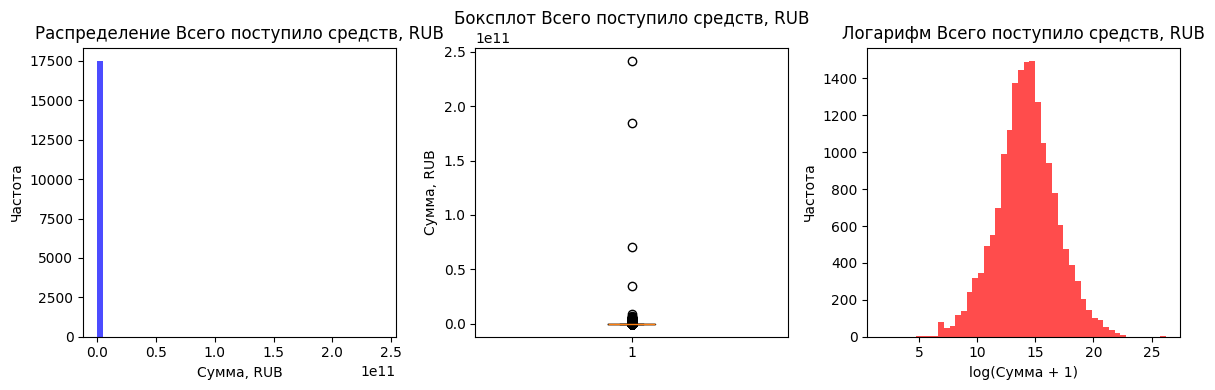


АНАЛИЗ ВЫБРОСОВ: Всего использовано средств, RUB
Всего значений: 17991
Мин: 4 RUB
Макс: 185,518,545,000 RUB
Медиана: 1,322,000 RUB
Среднее: 62,853,332 RUB
Стандартное отклонение: 2,123,251,759 RUB

Выбросы (IQR метод):
  Нижняя граница: -9,571,000 RUB
  Верхняя граница: 16,637,000 RUB
  Количество выбросов: 2799
  Процент выбросов: 15.6%

Топ-10 самых больших значений:
  1. 185,518,545,000 RUB
  2. 170,540,005,000 RUB
  3. 123,814,294,000 RUB
  4. 35,000,000,000 RUB
  5. 13,199,563,000 RUB
  6. 10,863,197,000 RUB
  7. 7,356,612,000 RUB
  8. 6,249,846,000 RUB
  9. 6,000,000,000 RUB
  10. 5,390,020,000 RUB


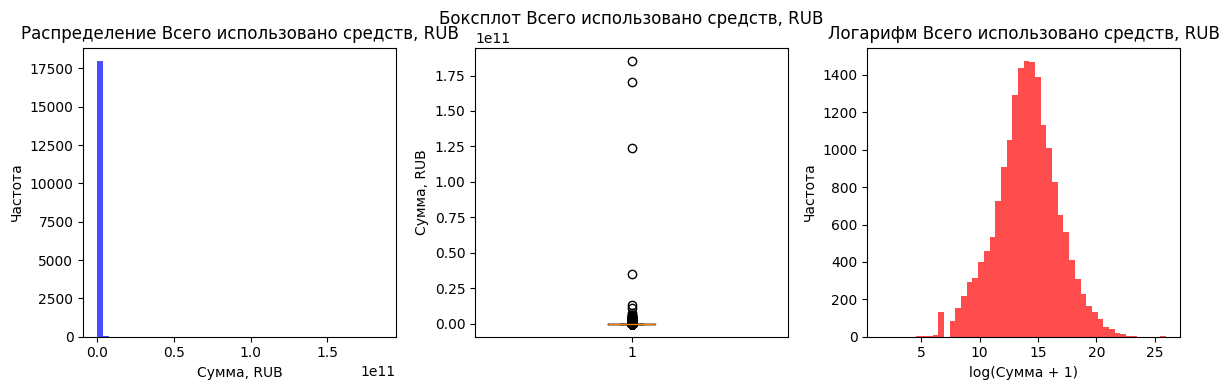


ЭКСТРЕМАЛЬНЫЕ ВЫБРОСЫ (>3 стандартных отклонений)

Всего поступило средств, RUB:
  Экстремальных выбросов: 5
  Значения экстремальных выбросов:
    - 70,200,000,000 RUB
    - 9,000,000,000 RUB
    - 241,986,640,000 RUB
    - 184,577,693,000 RUB
    - 35,000,000,000 RUB
  Организации с экстремальными значениями:
    - ФОНД ИМЕНИ АЛЕКСАНДРОВА (2018): 70,200,000,000 RUB
    - НАБАТ-3, БЛАГОТВОРИТЕЛЬНЫЙ ОБЩЕСТВЕННЫЙ ФОНД (2019): 9,000,000,000 RUB
    - ВЕРА В ДЕТСТВО, БФ (2020): 241,986,640,000 RUB
    - ВЕРА В ДЕТСТВО, БФ (2021): 184,577,693,000 RUB
    - ДАРАД, ФОНД (2021): 35,000,000,000 RUB

Всего использовано средств, RUB:
  Экстремальных выбросов: 7
  Значения экстремальных выбросов:
    - 123,814,294,000 RUB
    - 13,199,563,000 RUB
    - 7,356,612,000 RUB
    - 10,863,197,000 RUB
    - 185,518,545,000 RUB
    - 170,540,005,000 RUB
    - 35,000,000,000 RUB
  Организации с экстремальными значениями:
    - ФОНД ИМЕНИ АЛЕКСАНДРОВА (2018): 123,814,294,000 RUB
    - ФОНД ИМЕНИ АЛЕКСАНДР

In [11]:
df = pd.read_csv('data/merged_data6.csv', low_memory=False)

print("=== АНАЛИЗ ВЫБРОСОВ В ДОХОДАХ И РАСХОДАХ ===")

# Анализируем выбросы для доходов и расходов
columns_to_analyze = ['Всего поступило средств, RUB', 'Всего использовано средств, RUB']

for col in columns_to_analyze:
    print(f"\n{'='*50}")
    print(f"АНАЛИЗ ВЫБРОСОВ: {col}")
    print(f"{'='*50}")
    
    # Базовая статистика
    data = df[col].dropna()
    print(f"Всего значений: {len(data)}")
    print(f"Мин: {data.min():,.0f} RUB")
    print(f"Макс: {data.max():,.0f} RUB")
    print(f"Медиана: {data.median():,.0f} RUB")
    print(f"Среднее: {data.mean():,.0f} RUB")
    print(f"Стандартное отклонение: {data.std():,.0f} RUB")
    
    # Анализ выбросов через IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"\nВыбросы (IQR метод):")
    print(f"  Нижняя граница: {lower_bound:,.0f} RUB")
    print(f"  Верхняя граница: {upper_bound:,.0f} RUB")
    print(f"  Количество выбросов: {len(outliers)}")
    print(f"  Процент выбросов: {len(outliers)/len(data)*100:.1f}%")
    
    # Топ-10 самых больших значений
    print(f"\nТоп-10 самых больших значений:")
    top_values = data.nlargest(10)
    for i, value in enumerate(top_values, 1):
        print(f"  {i}. {value:,.0f} RUB")
    
    # Визуализация
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.hist(data, bins=50, alpha=0.7, color='blue')
    plt.title(f'Распределение {col}')
    plt.xlabel('Сумма, RUB')
    plt.ylabel('Частота')
    
    plt.subplot(1, 3, 2)
    plt.boxplot(data)
    plt.title(f'Боксплот {col}')
    plt.ylabel('Сумма, RUB')
    
    plt.subplot(1, 3, 3)
    # Логарифмическая шкала для лучшей визуализации
    log_data = np.log1p(data)  # log(1+x) чтобы избежать log(0)
    plt.hist(log_data, bins=50, alpha=0.7, color='red')
    plt.title(f'Логарифм {col}')
    plt.xlabel('log(Сумма + 1)')
    plt.ylabel('Частота')
    
    plt.tight_layout()
    plt.show()

# Анализ экстремальных выбросов (более 3 стандартных отклонений)
print(f"\n{'='*50}")
print("ЭКСТРЕМАЛЬНЫЕ ВЫБРОСЫ (>3 стандартных отклонений)")
print(f"{'='*50}")

for col in columns_to_analyze:
    data = df[col].dropna()
    mean = data.mean()
    std = data.std()
    extreme_outliers = data[np.abs(data - mean) > 3 * std]
    
    print(f"\n{col}:")
    print(f"  Экстремальных выбросов: {len(extreme_outliers)}")
    print(f"  Значения экстремальных выбросов:")
    for value in extreme_outliers:
        print(f"    - {value:,.0f} RUB")
    
    # Проверяем организации с экстремальными значениями
    if len(extreme_outliers) > 0:
        extreme_orgs = df[df[col].isin(extreme_outliers)][['Наименование', 'Год', col]]
        print(f"  Организации с экстремальными значениями:")
        for _, row in extreme_orgs.iterrows():
            print(f"    - {row['Наименование']} ({row['Год']}): {row[col]:,.0f} RUB")

In [ ]:
# визуализируем очищенные данные для поиска выбросов

=== АНАЛИЗ И УДАЛЕНИЕ ВЫБРОСОВ ===

Всего поступило средств, RUB
99% квантиль: 834,795,350 RUB
Максимум: 241,986,640,000 RUB
Количество выбросов (>99%): 175
Процент выбросов: 1.00%
Удалено выбросов: 175

Всего использовано средств, RUB
99% квантиль: 694,234,000 RUB
Максимум: 185,518,545,000 RUB
Количество выбросов (>99%): 180
Процент выбросов: 1.00%
Удалено выбросов: 180

✅ Сохранено в merged_data7.csv
Очищено строк: 55820

=== ВИЗУАЛИЗАЦИЯ ОЧИЩЕННЫХ ДАННЫХ ===

Всего поступило средств, RUB (после очистки)
Количество значений: 17321
Мин: 5 RUB
Макс: 834,708,000 RUB
Медиана: 1,487,000 RUB
Среднее: 18,646,436 RUB


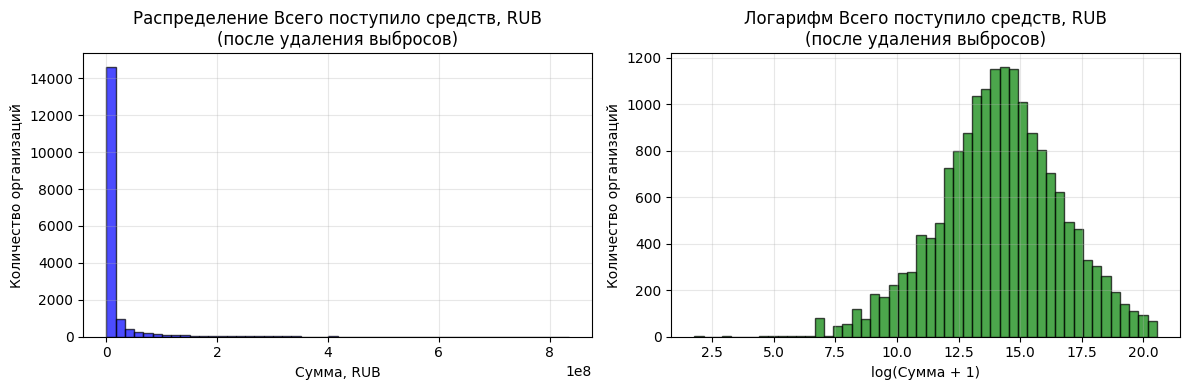


Всего использовано средств, RUB (после очистки)
Количество значений: 17811
Мин: 4 RUB
Макс: 694,157,000 RUB
Медиана: 1,283,000 RUB
Среднее: 16,523,846 RUB


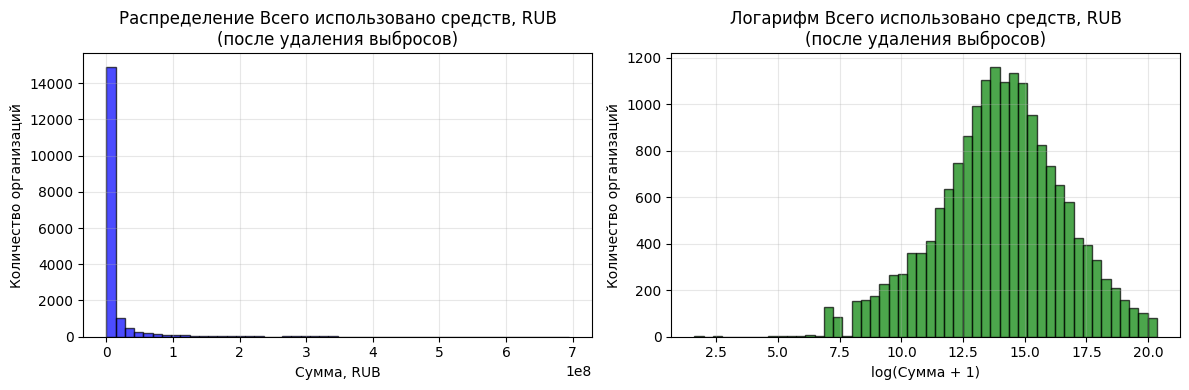


✅ Визуализация очищенных данных завершена


In [12]:
df = pd.read_csv('data/merged_data6.csv', low_memory=False)

print("=== АНАЛИЗ И УДАЛЕНИЕ ВЫБРОСОВ ===")

columns_to_analyze = ['Всего поступило средств, RUB', 'Всего использовано средств, RUB']

# Создаем копию для очистки
df_clean = df.copy()

for col in columns_to_analyze:
    print(f"\n{col}")
    
    data = df[col].dropna()
    
    # Анализ выбросов
    q99 = data.quantile(0.99)
    outliers_count = (data > q99).sum()
    
    print(f"99% квантиль: {q99:,.0f} RUB")
    print(f"Максимум: {data.max():,.0f} RUB")
    print(f"Количество выбросов (>99%): {outliers_count}")
    print(f"Процент выбросов: {outliers_count/len(data)*100:.2f}%")
    
    # Удаляем выбросы (заменяем на NaN)
    df_clean.loc[df_clean[col] > q99, col] = np.nan
    print(f"Удалено выбросов: {outliers_count}")

# Сохраняем очищенные данные
df_clean.to_csv('data/merged_data7.csv', index=False)
print(f"\n✅ Сохранено в merged_data7.csv")
print(f"Очищено строк: {len(df_clean)}")

print("\n=== ВИЗУАЛИЗАЦИЯ ОЧИЩЕННЫХ ДАННЫХ ===")

for col in columns_to_analyze:
    print(f"\n{col} (после очистки)")
    
    data_clean = df_clean[col].dropna()
    
    # Статистика после очистки
    print(f"Количество значений: {len(data_clean)}")
    print(f"Мин: {data_clean.min():,.0f} RUB")
    print(f"Макс: {data_clean.max():,.0f} RUB")
    print(f"Медиана: {data_clean.median():,.0f} RUB")
    print(f"Среднее: {data_clean.mean():,.0f} RUB")
    
    # Визуализация
    plt.figure(figsize=(12, 4))
    
    # 1. Гистограмма очищенных данных
    plt.subplot(1, 2, 1)
    plt.hist(data_clean, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f'Распределение {col}\n(после удаления выбросов)')
    plt.xlabel('Сумма, RUB')
    plt.ylabel('Количество организаций')
    plt.grid(alpha=0.3)
    
    # 2. Логарифм очищенных данных
    plt.subplot(1, 2, 2)
    log_data = np.log1p(data_clean)
    plt.hist(log_data, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.title(f'Логарифм {col}\n(после удаления выбросов)')
    plt.xlabel('log(Сумма + 1)')
    plt.ylabel('Количество организаций')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n✅ Визуализация очищенных данных завершена")

In [ ]:
# обнаружили существенные выбросы, мы удалим их и визуализируем данные еще раз

=== НОВЫЙ ВАРИАНТ ГРУППИРОВКИ ПО ЧИСЛЕННОСТИ ===
НОВОЕ РАСПРЕДЕЛЕНИЕ:
Крупные (151-1000): 12 организаций (0.0%)
Малые (1-15): 2562 организаций (4.6%)
Средние (16-150): 91 организаций (0.2%)


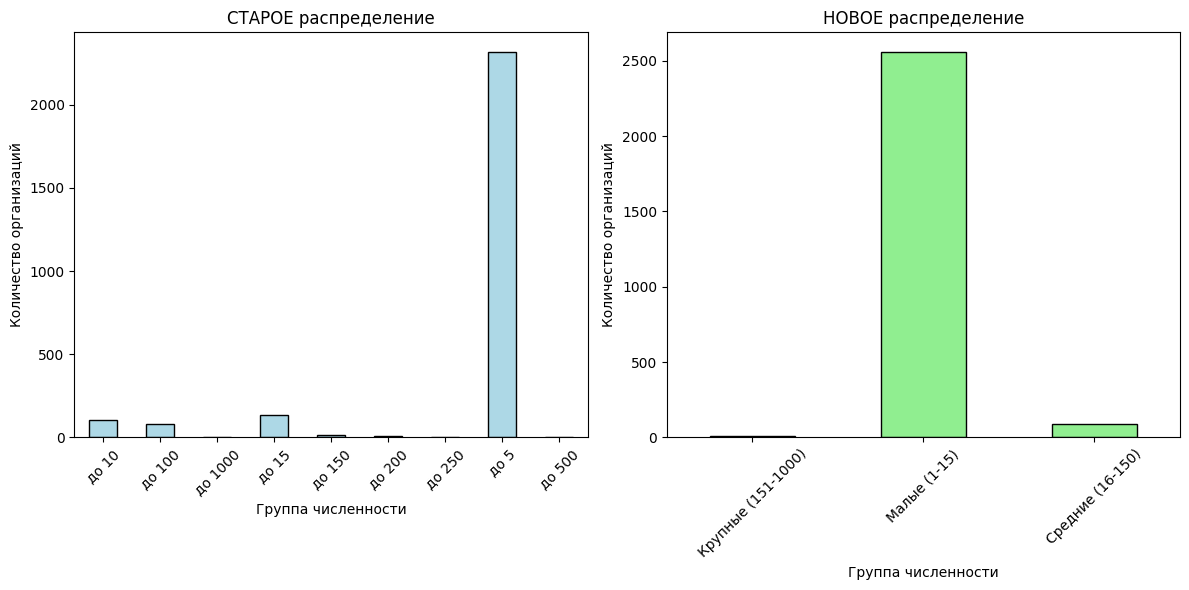


✅ Сохранено в merged_data8.csv с новой группировкой численности


In [13]:
df = pd.read_csv('data/merged_data7.csv', low_memory=False)

print("=== НОВЫЙ ВАРИАНТ ГРУППИРОВКИ ПО ЧИСЛЕННОСТИ ===")

# Текущее распределение
staff_distribution = df['численность_доп_признак'].value_counts().sort_index()

# Создаем новую группировку на основе данных
def create_new_staff_groups(current_group):
    if current_group in ['до 5', 'до 10', 'до 15']:
        return 'Малые (1-15)'
    elif current_group in ['до 100', 'до 150']:
        return 'Средние (16-150)' 
    elif current_group in ['до 200', 'до 250', 'до 500', 'до 1000']:
        return 'Крупные (151-1000)'
    else:
        return current_group

# Применяем новую группировку
df['численность_новая'] = df['численность_доп_признак'].apply(create_new_staff_groups)

# Смотрим новое распределение
new_distribution = df['численность_новая'].value_counts().sort_index()

print("НОВОЕ РАСПРЕДЕЛЕНИЕ:")
for group, count in new_distribution.items():
    print(f"{group}: {count} организаций ({count/len(df)*100:.1f}%)")

# Визуализация сравнения
plt.figure(figsize=(12, 6))

# Старое распределение
plt.subplot(1, 2, 1)
staff_distribution.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('СТАРОЕ распределение')
plt.xlabel('Группа численности')
plt.ylabel('Количество организаций')
plt.xticks(rotation=45)

# Новое распределение  
plt.subplot(1, 2, 2)
new_distribution.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('НОВОЕ распределение')
plt.xlabel('Группа численности')
plt.ylabel('Количество организаций')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Сохраняем данные с новой группировкой
df.to_csv('data/merged_data8.csv', index=False)
print(f"\n✅ Сохранено в merged_data8.csv с новой группировкой численности")

In [ ]:
# последним изменением будет объединение орагнизаций по численности в большие группы для дальнейшего анализа

***

# Проверка, есть ли связь между материальным благополучием фонда и количеством штатных работников (для тех организаций, которые подали отчётность)

# проверяем, верна ли гипотеза "Существует статистически значимая разница в материальном благополучии между организациями разного размера (малые, средние, крупные)"

In [14]:
df = pd.read_csv('data/merged_data8.csv', low_memory=False)

# Создаем прибыль
df['Прибыль'] = df['Всего поступило средств, RUB'] - df['Всего использовано средств, RUB']

# Фильтруем организации с отчетностью
mask = (
    df['Всего поступило средств, RUB'].notna() & 
    df['Всего использовано средств, RUB'].notna() &
    df['численность_новая'].notna()
)
df_analysis = df[mask]

# Проверяем нормальность распределения прибыли для каждой группы
print("ТЕСТ НОРМАЛЬНОСТИ ШАПИРО-УИЛКА:")
for group_name in ['Малые (1-15)', 'Средние (16-150)', 'Крупные (151-1000)']:
    group_data = df_analysis[df_analysis['численность_новая'] == group_name]['Прибыль'].dropna()
    stat, p_val = stats.shapiro(group_data)
    print(f"{group_name}: p-value = {p_val:.6f}")

ТЕСТ НОРМАЛЬНОСТИ ШАПИРО-УИЛКА:
Малые (1-15): p-value = 0.000000
Средние (16-150): p-value = 0.000000
Крупные (151-1000): p-value = 0.047616


In [ ]:
# начнем исследования со статистического теста, определим нормальное ли распределение

In [15]:
df = pd.read_csv('data/merged_data8.csv', low_memory=False)

# Создаем прибыль
df['Прибыль'] = df['Всего поступило средств, RUB'] - df['Всего использовано средств, RUB']

# Фильтруем организации с отчетностью
mask = (
    df['Всего поступило средств, RUB'].notna() & 
    df['Всего использовано средств, RUB'].notna() &
    df['численность_новая'].notna()
)
df_analysis = df[mask]

# Подготавливаем данные для теста Краскела-Уоллиса
groups = []
for group_name in ['Малые (1-15)', 'Средние (16-150)', 'Крупные (151-1000)']:
    group_data = df_analysis[df_analysis['численность_новая'] == group_name]['Прибыль'].dropna()
    groups.append(group_data)

# Проводим тест Краскела-Уоллиса
h_stat, p_value = stats.kruskal(*groups)

print(f"Тест Краскела-Уоллиса:")
print(f"H-статистика: {h_stat:.4f}")
print(f"p-value: {p_value:.6f}")

Тест Краскела-Уоллиса:
H-статистика: 14.7010
p-value: 0.000642


In [ ]:
# на основе ненормальности распределения данных, применяем тест Краскела-Уоллиса, который показывает:
# H-статистика: 14.7010
# p-value: 0.000642

# это означает, что существует сильная статистическая значимость и прибыль различается между малыми, средними и крупными организациями

In [16]:
df = pd.read_csv('data/merged_data8.csv', low_memory=False)

# Создаем прибыль
df['Прибыль'] = df['Всего поступило средств, RUB'] - df['Всего использовано средств, RUB']

# Фильтруем организации с отчетностью
mask = (
    df['Всего поступило средств, RUB'].notna() & 
    df['Всего использовано средств, RUB'].notna() &
    df['численность_новая'].notna()
)
df_analysis = df[mask].copy()  # Добавляем .copy() чтобы избежать предупреждения

print("=== АНАЛИЗ СИЛЫ СВЯЗИ ===")

# Метод 1: Корреляция Спирмена
size_rank = {'Малые (1-15)': 1, 'Средние (16-150)': 2, 'Крупные (151-1000)': 3}
df_analysis.loc[:, 'Размер_ранг'] = df_analysis['численность_новая'].map(size_rank)

correlation, p_value = stats.spearmanr(df_analysis['Прибыль'], df_analysis['Размер_ранг'])

# Метод 2: R² из Random Forest
le = LabelEncoder()
X = df_analysis[['численность_новая']].copy()
X['численность_код'] = le.fit_transform(X['численность_новая'])
X = X[['численность_код']]
y = df_analysis['Прибыль']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
r_squared = model.score(X, y)

print(f"1. Корреляция Спирмена: {correlation:.4f}")
print(f"2. R² из Random Forest: {r_squared:.4f}")
print(f"3. Объясняемая дисперсия: {r_squared*100:.2f}%")

=== АНАЛИЗ СИЛЫ СВЯЗИ ===
1. Корреляция Спирмена: 0.0744
2. R² из Random Forest: 0.0013
3. Объясняемая дисперсия: 0.13%


In [ ]:
# теперь попробуем узнать силу этой связи
# получаем:
# 1. Корреляция Спирмена: 0.0744
# 2. R² из Random Forest: 0.0013
# 3. Объясняемая дисперсия: 0.13%
# Это означает, что есть очень слабая положительная связь, т.е. статистически значимые отличия между группами есть, но правктического значения это нам не дает

попробуем использовать допущение и заполним пропуски в данных о численности штата 

In [18]:
from collections import Counter
df = pd.read_csv('data/merged_data8.csv', low_memory=False)

print("=== АНАЛИЗ ПАТТЕРНОВ ИЗМЕНЕНИЯ ЧИСЛЕННОСТИ ===")

# Сортируем по организации и году
df_sorted = df.sort_values(['Регистрационный номер', 'Год'])

# Собираем все изменения численности
changes = []

for reg_num, group in df_sorted.groupby('Регистрационный номер'):
    group = group[group['численность_новая'].notna()].sort_values('Год')
    
    if len(group) >= 2:
        for i in range(1, len(group)):
            prev = group.iloc[i-1]['численность_новая']
            curr = group.iloc[i]['численность_новая']
            
            if prev != curr:
                changes.append(f"{prev} → {curr}")
            else:
                changes.append(f"{prev} → без изменений")

# Анализируем частоту изменений
change_counts = Counter(changes)

print("ЧАСТОТА ИЗМЕНЕНИЙ ЧИСЛЕННОСТИ:")
for change, count in change_counts.most_common():
    percentage = count / len(changes) * 100
    print(f"  {change}: {count} раз ({percentage:.1f}%)")

print(f"\nВсего изменений: {len(changes)}")
print(f"Уникальных паттернов: {len(change_counts)}")

# Вероятности изменений
print(f"\nВЕРОЯТНОСТИ ИЗМЕНЕНИЙ:")
total_changes = len(changes)
no_change = sum(1 for c in changes if 'без изменений' in c)
actual_changes = total_changes - no_change

print(f"Вероятность изменения: {actual_changes/total_changes*100:.1f}%")
print(f"Вероятность стабильности: {no_change/total_changes*100:.1f}%")

=== АНАЛИЗ ПАТТЕРНОВ ИЗМЕНЕНИЯ ЧИСЛЕННОСТИ ===
ЧАСТОТА ИЗМЕНЕНИЙ ЧИСЛЕННОСТИ:
  Средние (16-150) → без изменений: 27 раз (54.0%)
  Малые (1-15) → Средние (16-150): 16 раз (32.0%)
  Крупные (151-1000) → без изменений: 4 раз (8.0%)
  Крупные (151-1000) → Средние (16-150): 1 раз (2.0%)
  Средние (16-150) → Крупные (151-1000): 1 раз (2.0%)
  Малые (1-15) → Крупные (151-1000): 1 раз (2.0%)

Всего изменений: 50
Уникальных паттернов: 6

ВЕРОЯТНОСТИ ИЗМЕНЕНИЙ:
Вероятность изменения: 38.0%
Вероятность стабильности: 62.0%


In [ ]:
# проверим можем ли мы предсказывать на основе имеющихся данных изменение численности
# получаем:
# ВЕРОЯТНОСТИ ИЗМЕНЕНИЙ:
# Вероятность изменения: 38.0%
# Вероятность стабильности: 62.0%

в 62% случаев при экстраполяции данных мы сохраняем последнюю известную численность
в 38% случаев для малых организаций увеличиваем численность до средних

=== ЭКСТРАПОЛЯЦИЯ ЧИСЛЕННОСТИ С УЧЕТОМ ВЕРОЯТНОСТЕЙ ===
Исходное состояние:
  Строк с полными данными: 1742
После экстраполяции:
  Строк с полными данными: 8273
  Заполнено пропусков: 6531
✅ Сохранено в merged_data8_1.csv


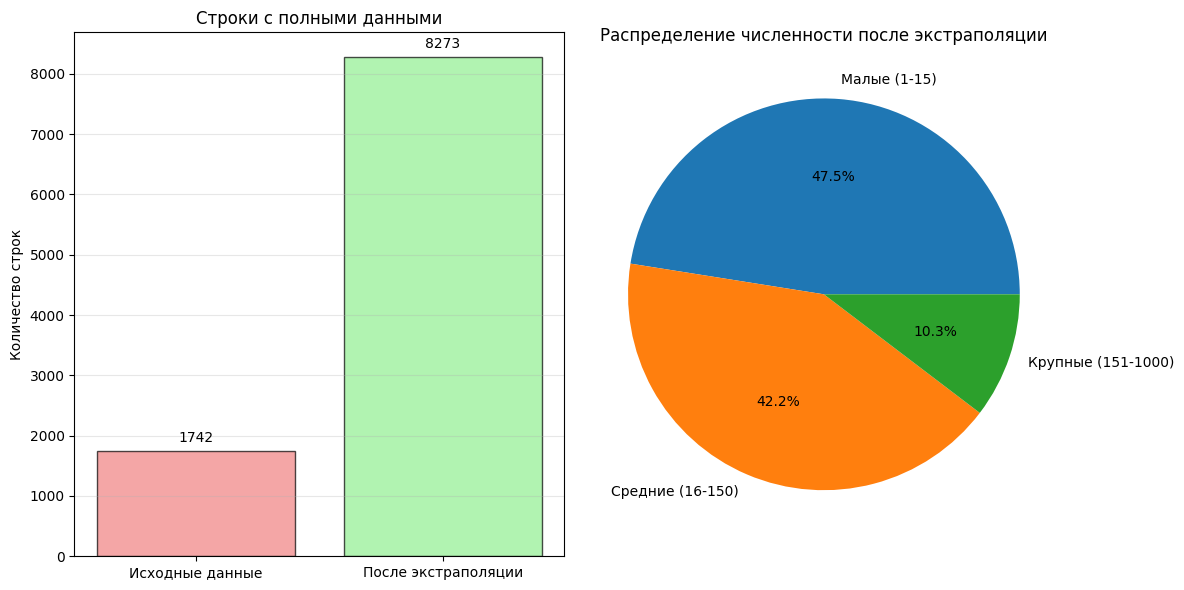


РАСПРЕДЕЛЕНИЕ ЧИСЛЕННОСТИ ПОСЛЕ ЭКСТРАПОЛЯЦИИ:
  Малые (1-15): 6210 организаций
  Средние (16-150): 5512 организаций
  Крупные (151-1000): 1353 организаций


In [19]:
df = pd.read_csv('data/merged_data8.csv', low_memory=False)

print("=== ЭКСТРАПОЛЯЦИЯ ЧИСЛЕННОСТИ С УЧЕТОМ ВЕРОЯТНОСТЕЙ ===")

# Сохраняем исходное состояние
initial_complete = df[
    df['численность_новая'].notna() & 
    df['Всего поступило средств, RUB'].notna() & 
    df['Всего использовано средств, RUB'].notna()
]

print(f"Исходное состояние:")
print(f"  Строк с полными данными: {len(initial_complete)}")

# Создаем копию для экстраполяции
df_extrapolated = df.copy().sort_values(['Регистрационный номер', 'Год'])

# Функция для экстраполяции с учетом вероятностей
def extrapolate_with_probabilities(group):
    group = group.copy()
    
    # Заполняем пропуски
    for i in range(len(group)):
        if pd.isna(group.iloc[i]['численность_новая']):
            # Находим последнюю известную численность
            known_data = group[group['численность_новая'].notna()]
            if len(known_data) > 0:
                last_known = known_data.iloc[-1]['численность_новая']
                
                # Генерируем случайное число для определения изменения
                rand = np.random.random()
                
                if rand <= 0.62:  # 62% - без изменений
                    new_staff = last_known
                elif rand <= 0.94:  # 32% - Малые → Средние
                    if last_known == 'Малые (1-15)':
                        new_staff = 'Средние (16-150)'
                    else:
                        new_staff = last_known  # Для других групп оставляем как есть
                else:  # 6% - другие изменения
                    if last_known == 'Малые (1-15)':
                        new_staff = 'Крупные (151-1000)'
                    elif last_known == 'Средние (16-150)':
                        new_staff = 'Крупные (151-1000)'
                    elif last_known == 'Крупные (151-1000)':
                        new_staff = 'Средние (16-150)'
                    else:
                        new_staff = last_known
                
                group.iloc[i, group.columns.get_loc('численность_новая')] = new_staff
    
    return group

# Применяем экстраполяцию
np.random.seed(42)  # Для воспроизводимости
df_extrapolated = df_extrapolated.groupby('Регистрационный номер').apply(extrapolate_with_probabilities).reset_index(drop=True)

# Проверяем результат
final_complete = df_extrapolated[
    df_extrapolated['численность_новая'].notna() & 
    df_extrapolated['Всего поступило средств, RUB'].notna() & 
    df_extrapolated['Всего использовано средств, RUB'].notna()
]

print(f"После экстраполяции:")
print(f"  Строк с полными данными: {len(final_complete)}")
print(f"  Заполнено пропусков: {len(final_complete) - len(initial_complete)}")

# Сохраняем результат
df_extrapolated.to_csv('data/merged_data8_1.csv', index=False)
print(f"✅ Сохранено в merged_data8_1.csv")

# Визуализация
plt.figure(figsize=(12, 6))

# График 1: Сравнение количества полных данных
plt.subplot(1, 2, 1)
categories = ['Исходные данные', 'После экстраполяции']
values = [len(initial_complete), len(final_complete)]

plt.bar(categories, values, color=['lightcoral', 'lightgreen'], alpha=0.7, edgecolor='black')
plt.title('Строки с полными данными')
plt.ylabel('Количество строк')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')

# График 2: Распределение численности после экстраполяции
plt.subplot(1, 2, 2)
staff_distribution = df_extrapolated['численность_новая'].value_counts()
plt.pie(staff_distribution.values, labels=staff_distribution.index, autopct='%1.1f%%')
plt.title('Распределение численности после экстраполяции')

plt.tight_layout()
plt.show()

print(f"\nРАСПРЕДЕЛЕНИЕ ЧИСЛЕННОСТИ ПОСЛЕ ЭКСТРАПОЛЯЦИИ:")
for group, count in staff_distribution.items():
    print(f"  {group}: {count} организаций")

In [ ]:
# Заполнено пропусков: 6531

In [20]:
df = pd.read_csv('data/merged_data8_1.csv', low_memory=False)

print("=== АНАЛИЗ ДЛЯ ЭКСТРАПОЛИРОВАННЫХ ДАННЫХ ===")

# Создаем прибыль
df['Прибыль'] = df['Всего поступило средств, RUB'] - df['Всего использовано средств, RUB']

# Фильтруем организации с отчетностью
mask = (
    df['Всего поступило средств, RUB'].notna() & 
    df['Всего использовано средств, RUB'].notna() &
    df['численность_новая'].notna()
)
df_analysis = df[mask]

print(f"Организаций для анализа: {len(df_analysis)}")

# 1. Тест Краскела-Уоллиса
groups = []
for group_name in ['Малые (1-15)', 'Средние (16-150)', 'Крупные (151-1000)']:
    group_data = df_analysis[df_analysis['численность_новая'] == group_name]['Прибыль'].dropna()
    groups.append(group_data)

h_stat, p_value = stats.kruskal(*groups)

# 2. Корреляция Спирмена
size_rank = {'Малые (1-15)': 1, 'Средние (16-150)': 2, 'Крупные (151-1000)': 3}
df_analysis['Размер_ранг'] = df_analysis['численность_новая'].map(size_rank)
correlation, p_corr = stats.spearmanr(df_analysis['Прибыль'], df_analysis['Размер_ранг'])

# 3. R² из Random Forest
le = LabelEncoder()
X = df_analysis[['численность_новая']].copy()
X['численность_код'] = le.fit_transform(X['численность_новая'])
X = X[['численность_код']]
y = df_analysis['Прибыль']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
r_squared = model.score(X, y)

print(f"Тест Краскела-Уоллиса: p-value = {p_value:.6f}")
print(f"Корреляция Спирмена: {correlation:.4f}")
print(f"R²: {r_squared:.4f}")
print(f"Объясняемая дисперсия: {r_squared*100:.2f}%")

=== АНАЛИЗ ДЛЯ ЭКСТРАПОЛИРОВАННЫХ ДАННЫХ ===
Организаций для анализа: 8273
Тест Краскела-Уоллиса: p-value = 0.027344
Корреляция Спирмена: 0.0294
R²: 0.0001
Объясняемая дисперсия: 0.01%


In [ ]:
# экстраполяция размыла связь, но основной вывод остался прежним - связь есть, но практически незначима

# Определим факторы, влияющие на закредитованность, финансовое благополучие организации

проверяем, верна ли гипотеза: есть один или несколько факторов, влияющие на закредитованность, финансовое благополучие организации


In [21]:
df = pd.read_csv('data/merged_data8.csv', low_memory=False)

print("=== УДАЛЕНИЕ ВЫБРОСОВ ИЗ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ ===")

# Финансовые показатели для очистки
financial_metrics = [
    'Дебиторская задолженность, RUB',
    'Заёмные средства (краткосрочные), RUB', 
    'Кредиторская задолженность, RUB'
]

df_clean = df.copy()

for metric in financial_metrics:
    print(f"\n{metric}:")
    data = df[metric].dropna()
    
    if len(data) > 0:
        # Анализ выбросов через IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        print(f"  Выбросов (IQR): {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
        
        # Удаляем выбросы (заменяем на NaN)
        outlier_mask = (df_clean[metric] < lower_bound) | (df_clean[metric] > upper_bound)
        df_clean.loc[outlier_mask, metric] = np.nan
        
        print(f"  Удалено значений: {outlier_mask.sum()}")
        
        # Статистика после очистки
        clean_data = df_clean[metric].dropna()
        print(f"  Осталось значений: {len(clean_data)}")
        print(f"  Новый диапазон: {clean_data.min():,.0f} - {clean_data.max():,.0f} RUB")

# Сохраняем очищенные данные
df_clean.to_csv('data/merged_data9_financial.csv', index=False)
print(f"\n✅ Сохранено в merged_data9_financial.csv")

=== УДАЛЕНИЕ ВЫБРОСОВ ИЗ ФИНАНСОВЫХ ПОКАЗАТЕЛЕЙ ===

Дебиторская задолженность, RUB:
  Выбросов (IQR): 2099 (16.4%)
  Удалено значений: 2099
  Осталось значений: 10680
  Новый диапазон: 1 - 2,335,000 RUB

Заёмные средства (краткосрочные), RUB:
  Выбросов (IQR): 334 (17.1%)
  Удалено значений: 334
  Осталось значений: 1616
  Новый диапазон: -800,000 - 1,607,000 RUB

Кредиторская задолженность, RUB:
  Выбросов (IQR): 1930 (15.9%)
  Удалено значений: 1930
  Осталось значений: 10182
  Новый диапазон: 5 - 1,057,000 RUB

✅ Сохранено в merged_data9_financial.csv


In [ ]:
# удаляем выбросы из необходимых переменных

=== СОЗДАНИЕ КОМПЛЕКСНОГО КОЭФФИЦИЕНТА ЗАКРЕДИТОВАННОСТИ ===
Заёмные средства (краткосрочные), RUB: 1616 значений
Кредиторская задолженность, RUB: 10182 значений
Дебиторская задолженность, RUB: 10680 значений

Комплексный коэффициент создан:
  Организаций с расчетом: 620
  Диапазон: 0.002 - 1.433
  Медиана: 0.638

РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТА:
  низкая: 82 орг. (0.0-0.3)
  умеренная: 202 орг. (0.3-0.6)
  высокая: 137 орг. (0.6-0.8)
  критическая: 197 орг. (0.8-1.0)

КОРРЕЛЯЦИЯ С ИСХОДНЫМИ ПАРАМЕТРАМИ:
  С заёмными средствами: 0.209
  С кредиторской задолженностью: 0.085
  С дебиторской задолженностью: -0.581

✅ Сохранено в merged_data10_with_coeff.csv
=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КОЭФФИЦИЕНТА ЗАКРЕДИТОВАННОСТИ ===


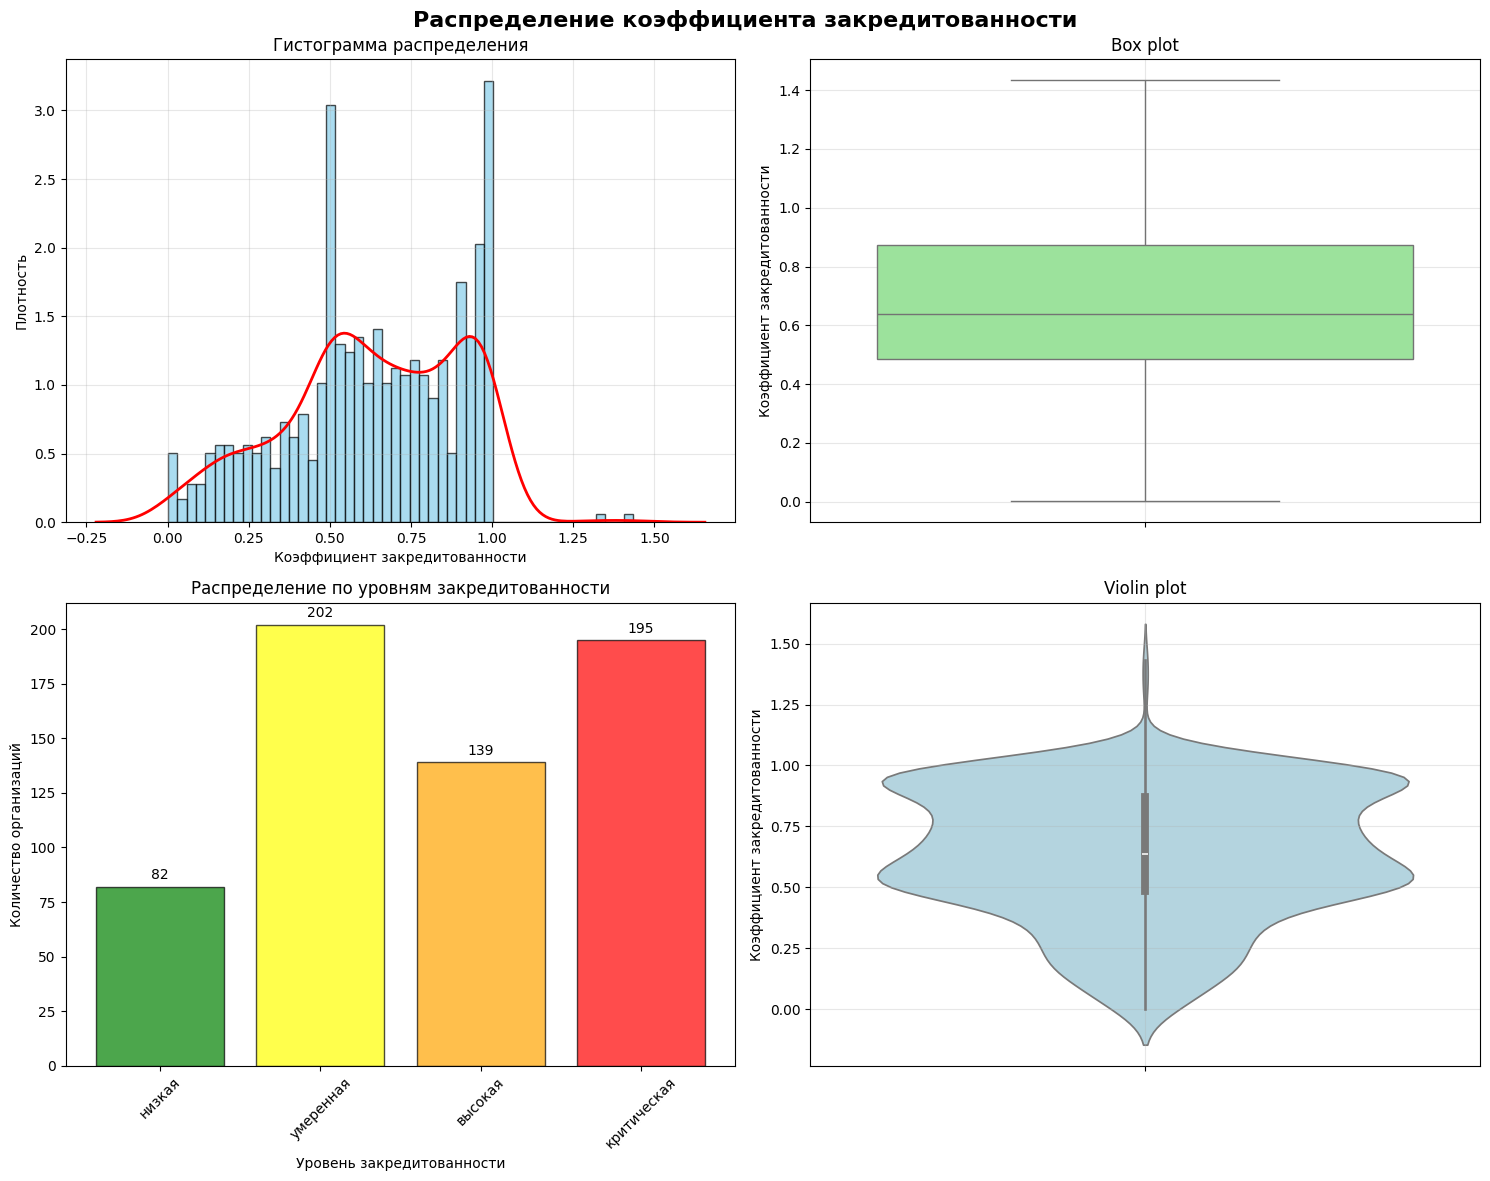


=== СТАТИСТИЧЕСКИЙ АНАЛИЗ ===
Общее количество организаций: 620
Среднее значение: 0.633
Медиана: 0.638
Стандартное отклонение: 0.268
Асимметрия: -0.343
Эксцесс: -0.604

Квартили:
  25%: 0.485
  50%: 0.638
  75%: 0.872
  90%: 0.974
  95%: 0.990

Выбросы (по методу IQR):
  Нижняя граница: -0.096
  Верхняя граница: 1.453
  Количество выбросов: 0
  Доля выбросов: 0.0%

=== ДЕТАЛЬНЫЙ АНАЛИЗ ПО УРОВНЯМ ===
Низкая закредитованность (82 орг.):
  Диапазон: 0.002 - 0.299
  Среднее: 0.164
Умеренная закредитованность (202 орг.):
  Диапазон: 0.301 - 0.599
  Среднее: 0.483
Высокая закредитованность (139 орг.):
  Диапазон: 0.607 - 0.800
  Среднее: 0.702
Критическая закредитованность (195 орг.):
  Диапазон: 0.803 - 0.999
  Среднее: 0.929

✅ Данные сохранены в merged_data10_with_coeff_and_levels.csv


In [22]:
df = pd.read_csv('data/merged_data9_financial.csv', low_memory=False)

print("=== СОЗДАНИЕ КОМПЛЕКСНОГО КОЭФФИЦИЕНТА ЗАКРЕДИТОВАННОСТИ ===")

# Проверяем наличие данных
required_cols = [
    'Заёмные средства (краткосрочные), RUB',
    'Кредиторская задолженность, RUB',
    'Дебиторская задолженность, RUB'
]

for col in required_cols:
    non_null = df[col].notna().sum()
    print(f"{col}: {non_null} значений")

# Создаем комплексный коэффициент
mask = (
    df['Заёмные средства (краткосрочные), RUB'].notna() & 
    df['Кредиторская задолженность, RUB'].notna() &
    df['Дебиторская задолженность, RUB'].notna()
)

# Комплексный коэффициент закредитованности
df['Общие_обязательства'] = df['Заёмные средства (краткосрочные), RUB'] + df['Кредиторская задолженность, RUB']
df['Коэф_закредитованности'] = df['Общие_обязательства'] / (df['Общие_обязательства'] + df['Дебиторская задолженность, RUB'])

print(f"\nКомплексный коэффициент создан:")
print(f"  Организаций с расчетом: {df['Коэф_закредитованности'].notna().sum()}")
print(f"  Диапазон: {df['Коэф_закредитованности'].min():.3f} - {df['Коэф_закредитованности'].max():.3f}")
print(f"  Медиана: {df['Коэф_закредитованности'].median():.3f}")

# Анализ распределения
print(f"\nРАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТА:")
coeff_data = df['Коэф_закредитованности'].dropna()
bins = [0, 0.3, 0.6, 0.8, 1.0]
labels = ['низкая', 'умеренная', 'высокая', 'критическая']

for i in range(len(bins)-1):
    count = ((coeff_data >= bins[i]) & (coeff_data < bins[i+1])).sum()
    print(f"  {labels[i]}: {count} орг. ({bins[i]:.1f}-{bins[i+1]:.1f})")

# Проверка корреляции с исходными параметрами
print(f"\nКОРРЕЛЯЦИЯ С ИСХОДНЫМИ ПАРАМЕТРАМИ:")
corr_loan = df['Коэф_закредитованности'].corr(df['Заёмные средства (краткосрочные), RUB'])
corr_creditor = df['Коэф_закредитованности'].corr(df['Кредиторская задолженность, RUB']) 
corr_debtor = df['Коэф_закредитованности'].corr(df['Дебиторская задолженность, RUB'])

print(f"  С заёмными средствами: {corr_loan:.3f}")
print(f"  С кредиторской задолженностью: {corr_creditor:.3f}")
print(f"  С дебиторской задолженностью: {corr_debtor:.3f}")

# Сохраняем с новым признаком
df.to_csv('data/merged_data10_with_coeff.csv', index=False)
print(f"\n✅ Сохранено в merged_data10_with_coeff.csv")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройка стиля графиков
plt.style.use('default')
sns.set_palette("husl")

# Загружаем данные
df = pd.read_csv('data/merged_data10_with_coeff.csv', low_memory=False)

print("=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КОЭФФИЦИЕНТА ЗАКРЕДИТОВАННОСТИ ===")

# Создаем фигуру с несколькими subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Распределение коэффициента закредитованности', fontsize=16, fontweight='bold')

# 1. Гистограмма с KDE
coeff_data = df['Коэф_закредитованности'].dropna()
axes[0, 0].hist(coeff_data, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
axes[0, 0].set_xlabel('Коэффициент закредитованности')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].set_title('Гистограмма распределения')
axes[0, 0].grid(True, alpha=0.3)

# Добавляем KDE
sns.kdeplot(coeff_data, ax=axes[0, 0], color='red', linewidth=2)

# 2. Box plot
sns.boxplot(y=coeff_data, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_ylabel('Коэффициент закредитованности')
axes[0, 1].set_title('Box plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Категоризированное распределение по уровням закредитованности
bins = [0, 0.3, 0.6, 0.8, 1.0]
labels = ['низкая', 'умеренная', 'высокая', 'критическая']
df['Уровень_закредитованности'] = pd.cut(df['Коэф_закредитованности'], bins=bins, labels=labels, include_lowest=True)

level_counts = df['Уровень_закредитованности'].value_counts().sort_index()
colors = ['green', 'yellow', 'orange', 'red']
axes[1, 0].bar(level_counts.index, level_counts.values, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Уровень закредитованности')
axes[1, 0].set_ylabel('Количество организаций')
axes[1, 0].set_title('Распределение по уровням закредитованности')
axes[1, 0].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for i, v in enumerate(level_counts.values):
    axes[1, 0].text(i, v + max(level_counts.values)*0.01, str(v), ha='center', va='bottom')

# 4. Violin plot
sns.violinplot(y=coeff_data, ax=axes[1, 1], color='lightblue')
axes[1, 1].set_ylabel('Коэффициент закредитованности')
axes[1, 1].set_title('Violin plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n=== СТАТИСТИЧЕСКИЙ АНАЛИЗ ===")
print(f"Общее количество организаций: {len(coeff_data)}")
print(f"Среднее значение: {coeff_data.mean():.3f}")
print(f"Медиана: {coeff_data.median():.3f}")
print(f"Стандартное отклонение: {coeff_data.std():.3f}")
print(f"Асимметрия: {coeff_data.skew():.3f}")
print(f"Эксцесс: {coeff_data.kurtosis():.3f}")

# Квартили
print(f"\nКвартили:")
print(f"  25%: {coeff_data.quantile(0.25):.3f}")
print(f"  50%: {coeff_data.quantile(0.50):.3f}")
print(f"  75%: {coeff_data.quantile(0.75):.3f}")
print(f"  90%: {coeff_data.quantile(0.90):.3f}")
print(f"  95%: {coeff_data.quantile(0.95):.3f}")

# Анализ выбросов
Q1 = coeff_data.quantile(0.25)
Q3 = coeff_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = coeff_data[(coeff_data < lower_bound) | (coeff_data > upper_bound)]
print(f"\nВыбросы (по методу IQR):")
print(f"  Нижняя граница: {lower_bound:.3f}")
print(f"  Верхняя граница: {upper_bound:.3f}")
print(f"  Количество выбросов: {len(outliers)}")
print(f"  Доля выбросов: {len(outliers)/len(coeff_data)*100:.1f}%")

# Детальный анализ по уровням
print(f"\n=== ДЕТАЛЬНЫЙ АНАЛИЗ ПО УРОВНЯМ ===")
for level in labels:
    level_data = df[df['Уровень_закредитованности'] == level]['Коэф_закредитованности']
    if len(level_data) > 0:
        print(f"{level.capitalize()} закредитованность ({len(level_data)} орг.):")
        print(f"  Диапазон: {level_data.min():.3f} - {level_data.max():.3f}")
        print(f"  Среднее: {level_data.mean():.3f}")

# Сохраняем данные с уровнями закредитованности
df.to_csv('data/merged_data10_with_coeff_and_levels.csv', index=False)
print(f"\n✅ Данные сохранены в merged_data10_with_coeff_and_levels.csv")

In [ ]:
# создаем коэффициент закредитованности

In [25]:
df = pd.read_csv('data/merged_data10_with_coeff_and_levels.csv', low_memory=False)

print("=== ЧИСТЫЙ АНАЛИЗ ФАКТОРОВ ВЛИЯНИЯ НА ЗАКРЕДИТОВАННОСТЬ ===\n")

# ИСКЛЮЧАЕМ параметры, входящие в коэффициент и технические поля
exclude_cols = [
    # Параметры, из которых состоит коэффициент
    'Заёмные средства (краткосрочные), RUB',
    'Кредиторская задолженность, RUB', 
    'Дебиторская задолженность, RUB',
    'Общие_обязательства',
    'Коэф_закредитованности',
    
    # Технические/идентификационные поля
    'Наименование',
    'Дата регистрации',
    'Регистрационный номер',  # Добавляем - это идентификатор!
    
    # Сама целевая переменная
    'Уровень_закредитованности'
]

# Все остальные столбцы для анализа
all_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Анализируем {len(all_cols)} параметров...")
print(f"Доступно записей с уровнем закредитованности: {df['Уровень_закредитованности'].notna().sum()} из {len(df)}")

results = []

for col in all_cols:
    # Убираем пропуски
    mask = df['Уровень_закредитованности'].notna() & df[col].notna()
    data = df[mask]
    
    # УСЛАБЛЯЕМ УСЛОВИЯ для тестирования
    if len(data) > 10:  # было 30
        # Для числовых данных
        if data[col].dtype in ['float64', 'int64']:
            groups = []
            for level in data['Уровень_закредитованности'].unique():
                group_data = data[data['Уровень_закредитованности'] == level][col]
                if len(group_data) > 2:  # было 3
                    groups.append(group_data)
            
            if len(groups) >= 2:
                try:
                    from scipy.stats import kruskal
                    stat, p_value = kruskal(*groups)
                    results.append({
                        'параметр': col,
                        'тип': 'числовой',
                        'p_value': p_value,
                        'наблюдения': len(data),
                        'группы': len(groups)
                    })
                    print(f"✓ Числовой: {col} - p={p_value:.6f}")
                except Exception as e:
                    print(f"✗ Ошибка в {col}: {e}")
                    continue
        
        # Для категориальных данных
        else:
            try:
                from scipy.stats import chi2_contingency
                # Создаем таблицу сопряженности
                contingency_table = pd.crosstab(data[col], data['Уровень_закредитованности'])
                if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
                    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
                    results.append({
                        'параметр': col,
                        'тип': 'категориальный',
                        'p_value': p_value,
                        'наблюдения': len(data),
                        'группы': f"{contingency_table.shape[0]}x{contingency_table.shape[1]}"
                    })
                    print(f"✓ Категориальный: {col} - p={p_value:.6f}")
            except Exception as e:
                print(f"✗ Ошибка в {col}: {e}")
                continue

print(f"\nНайдено результатов для анализа: {len(results)}")

# ПРОВЕРКА ПЕРЕД СОЗДАНИЕМ DATAFRAME
if len(results) == 0:
    print("\n❌ Нет данных для анализа! Возможные причины:")
    print("1. Слишком много пропусков в данных")
    print("2. Недостаточно наблюдений после фильтрации") 
    print("3. Все столбцы исключены из анализа")
    print("\nРекомендации:")
    print("- Проверьте заполненность столбцов")
    print("- Увеличьте допустимое количество пропусков")
    print("- Убедитесь, что есть данные с разными уровнями закредитованности")
    
    # Создаем пустой DataFrame с нужными колонками
    results_df = pd.DataFrame(columns=['параметр', 'тип', 'p_value', 'наблюдения', 'группы'])
    significant_results = results_df
else:
    # Сортируем по значимости
    results_df = pd.DataFrame(results).sort_values('p_value')
    # Все значимые факторы (p < 0.05)
    significant_results = results_df[results_df['p_value'] < 0.05]

# ДАЛЕЕ ВАШ СУЩЕСТВУЮЩИЙ КОД ДЛЯ ВЫВОДА РЕЗУЛЬТАТОВ...
print(f"НАЙДЕНО СТАТИСТИЧЕСКИ ЗНАЧИМЫХ ФАКТОРОВ: {len(significant_results)} из {len(all_cols)}\n")

if len(significant_results) > 0:
    print("ВСЕ ЗНАЧИМЫЕ ФАКТОРЫ ВЛИЯНИЯ НА УРОВЕНЬ ЗАКРЕДИТОВАННОСТИ:")
    print("=" * 80)

    for i, row in significant_results.iterrows():
        significance = '***' if row['p_value'] < 0.001 else '**' if row['p_value'] < 0.01 else '*'
        print(f"{i+1:2d}. {row['параметр']}")
        print(f"     Тип: {row['тип']}, p-value: {row['p_value']:.6f} {significance}")
        print(f"     Наблюдений: {row['наблюдения']}")
        print()
else:
    print("❌ Значимых факторов не найдено")

=== ЧИСТЫЙ АНАЛИЗ ФАКТОРОВ ВЛИЯНИЯ НА ЗАКРЕДИТОВАННОСТЬ ===

Анализируем 31 параметров...
Доступно записей с уровнем закредитованности: 618 из 55820
✓ Категориальный: Регион регистрации - p=0.000000
✓ Категориальный: Организационно-правовая форма - p=0.026466
✓ Числовой: Год - p=0.637746
✓ Числовой: Валовая прибыль (убыток), RUB - p=0.083762
✓ Числовой: Всего использовано средств, RUB - p=0.284118
✓ Числовой: Всего поступило средств, RUB - p=0.123640
✓ Числовой: Выручка, RUB - p=0.110817
✓ Числовой: Денежные средства и денежные эквиваленты, RUB - p=0.778203
✓ Числовой: Капитал и резервы, RUB - p=0.000000
✓ Числовой: Коммерческие расходы, RUB - p=0.309946
✓ Числовой: Остаток средств на конец отчетного года, RUB - p=0.007209
✓ Числовой: Пассивы всего, RUB - p=0.000000
✓ Числовой: Прибыль (убыток) до налогообложения , RUB - p=0.005705
✓ Числовой: Прибыль (убыток) от продажи, RUB - p=0.021484
✓ Числовой: Прибыль от приносящей доход деятельности, RUB - p=0.798249
✓ Числовой: Приобретение ос

In [ ]:
# найдем факторы, которые могут быть связаны с нашей целевой переменной, это:
# Капитал и резервы, RUB (p=0.000000)
# - Пассивы всего, RUB (p=0.000000)
# - Регион регистрации (p=0.000000)

# Начнем более глубокий анализ и поиск факторов, влияющих на финансовое благополучие и закредитованность организаций

мы получили, что предварительно обнаружены факторы, связанные с нашей целевой переменной, начнем применять ML методы для определения важности факторов


=== ML АНАЛИЗ ВАЖНОСТИ ФАКТОРОВ ===
Размер датасета: (55820, 40)
Колонки: 40

Доступные факторы для анализа: 9 из 9
Итоговый размер данных для ML: (55820, 12)

🎯 1. КЛАССИФИКАЦИЯ: Факторы влияния на УРОВЕНЬ ЗАКРЕДИТОВАННОСТИ
Данные для классификации: (618, 9)

ВАЖНОСТЬ ПРИЗНАКОВ для классификации уровня закредитованности:
 2. Пассивы всего, RUB: 0.2162
 1. Капитал и резервы, RUB: 0.2130
 5. Остаток средств на конец отчетного года, RUB: 0.1341
 8. Регион_код: 0.1223
 3. Чистая прибыль (убыток), RUB: 0.0742
 4. Прибыль (убыток) до налогообложения , RUB: 0.0690
 7. Прибыль (убыток) от продажи, RUB: 0.0687
 6. Прочие расходы, RUB: 0.0674
 9. ОПФ_код: 0.0351

💰 2. РЕГРЕССИЯ: Факторы влияния на ФИНАНСОВОЕ БЛАГОПОЛУЧИЕ

📊 Факторы влияния на 'Всего использовано средств, RUB':
Данные для регрессии (использовано): (17811, 9)
 5. Остаток средств на конец отчетного года, RUB: 0.5588
 2. Пассивы всего, RUB: 0.1321
 1. Капитал и резервы, RUB: 0.0799
 8. Регион_код: 0.0678
 6. Прочие расходы, RUB: 0.

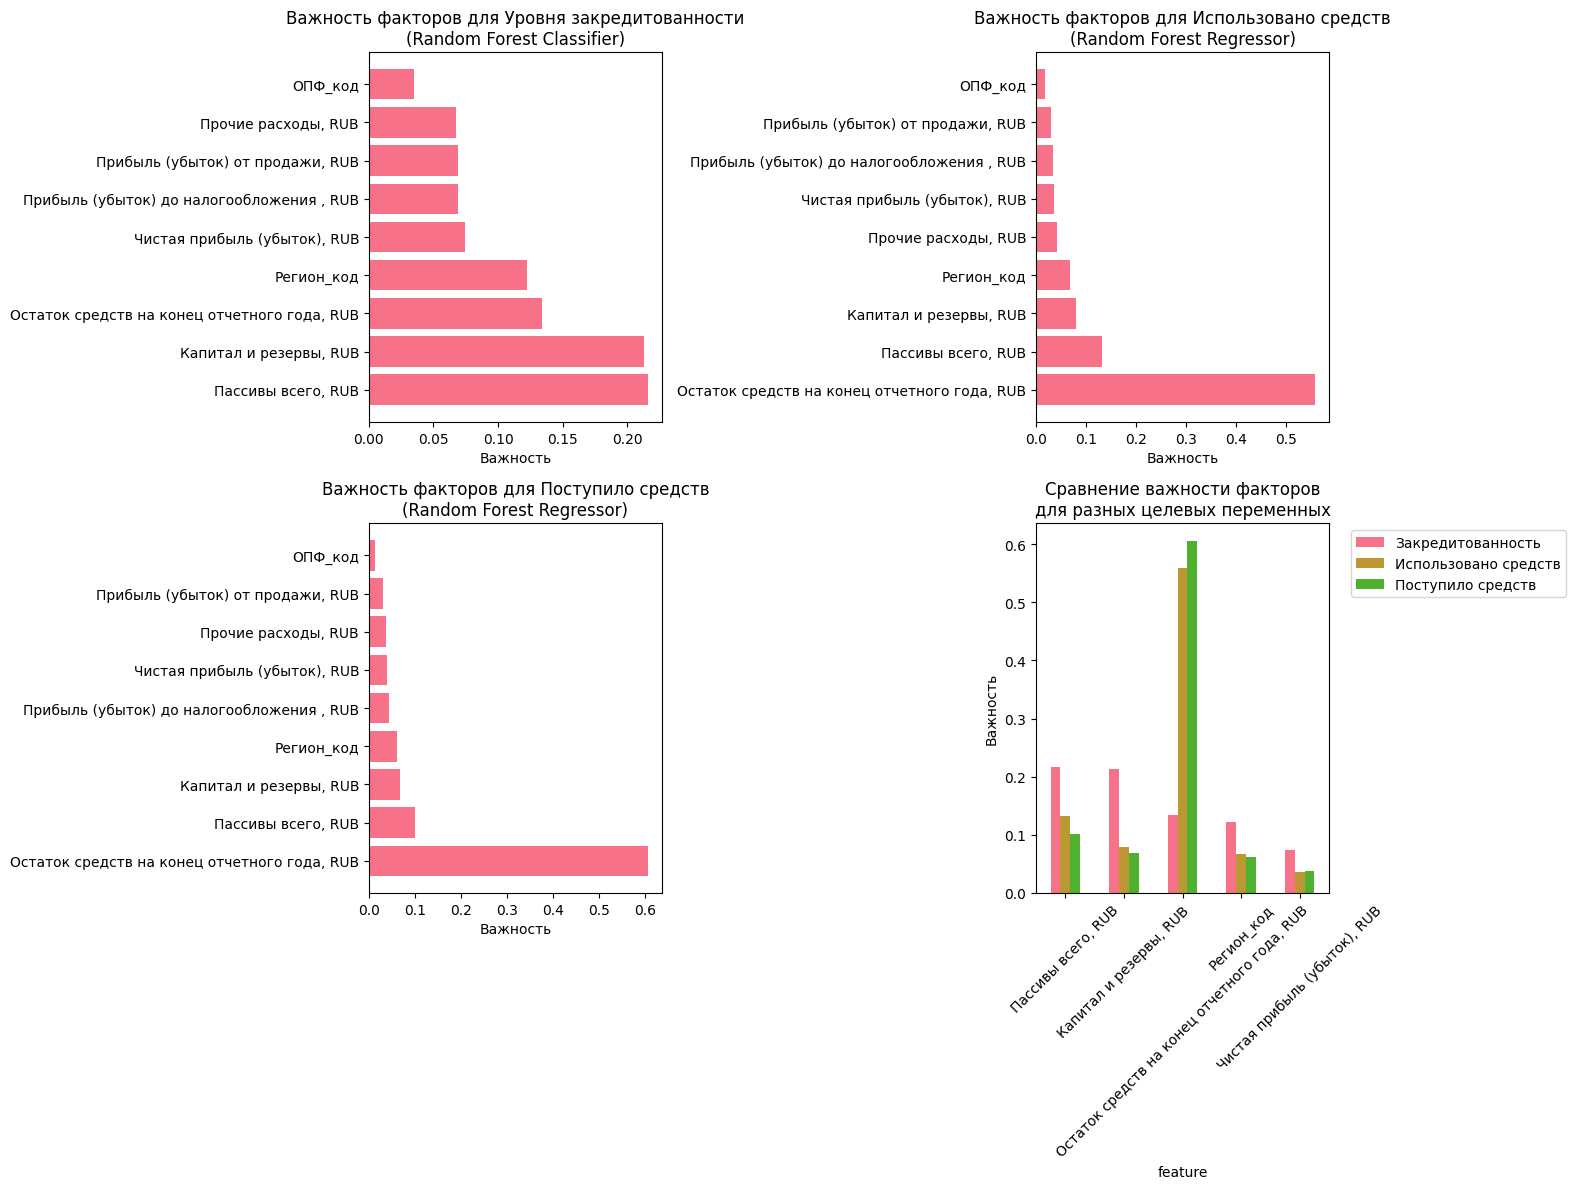


🎯 ИТОГОВАЯ СВОДКА ВАЖНЫХ ФАКТОРОВ:

ТОП-10 САМЫХ ВАЖНЫХ ФАКТОРОВ (по всем целевым переменным):
 1. Остаток средств на конец отчетного года, RUB
     Средняя важность: 0.4329
     Закредитованность: 0.1341
     Использовано средств: 0.5588
     Поступило средств: 0.6057

 2. Пассивы всего, RUB
     Средняя важность: 0.1497
     Закредитованность: 0.2162
     Использовано средств: 0.1321
     Поступило средств: 0.1007

 3. Капитал и резервы, RUB
     Средняя важность: 0.1203
     Закредитованность: 0.2130
     Использовано средств: 0.0799
     Поступило средств: 0.0679

 4. Регион_код
     Средняя важность: 0.0839
     Закредитованность: 0.1223
     Использовано средств: 0.0678
     Поступило средств: 0.0616

 5. Чистая прибыль (убыток), RUB
     Средняя важность: 0.0496
     Закредитованность: 0.0742
     Использовано средств: 0.0362
     Поступило средств: 0.0385

 6. Прибыль (убыток) до налогообложения , RUB
     Средняя важность: 0.0493
     Закредитованность: 0.0690
     Использова

In [26]:
df = pd.read_csv('data/merged_data10_with_coeff_and_levels.csv', low_memory=False)

print("=== ML АНАЛИЗ ВАЖНОСТИ ФАКТОРОВ ===")
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {len(df.columns)}")
print()

# Подготовка данных для ML
def prepare_ml_data(df, target_type='classification'):
    """Подготовка данных для машинного обучения"""
    
    # Берем только значимые факторы из нашего предыдущего анализа
    significant_factors = [
        'Капитал и резервы, RUB',
        'Пассивы всего, RUB', 
        'Чистая прибыль (убыток), RUB',
        'Прибыль (убыток) до налогообложения , RUB',
        'Остаток средств на конец отчетного года, RUB',
        'Прочие расходы, RUB',
        'Прибыль (убыток) от продажи, RUB',
        'Регион регистрации',
        'Организационно-правовая форма'
    ]
    
    # Проверяем, какие факторы есть в датасете
    available_factors = [f for f in significant_factors if f in df.columns]
    print(f"Доступные факторы для анализа: {len(available_factors)} из {len(significant_factors)}")
    
    # Создаем копию данных
    ml_df = df[available_factors + ['Уровень_закредитованности', 'Всего использовано средств, RUB', 'Всего поступило средств, RUB']].copy()
    
    # Кодируем категориальные переменные
    le = LabelEncoder()
    if 'Регион регистрации' in ml_df.columns:
        ml_df['Регион_код'] = le.fit_transform(ml_df['Регион регистрации'].fillna('Unknown'))
        ml_df = ml_df.drop('Регион регистрации', axis=1)
    
    if 'Организационно-правовая форма' in ml_df.columns:
        ml_df['ОПФ_код'] = le.fit_transform(ml_df['Организационно-правовая форма'].fillna('Unknown'))
        ml_df = ml_df.drop('Организационно-правовая форма', axis=1)
    
    print(f"Итоговый размер данных для ML: {ml_df.shape}")
    return ml_df

# Подготавливаем данные
ml_data = prepare_ml_data(df)

# 1. КЛАССИФИКАЦИЯ: Предсказание уровня закредитованности
print("\n🎯 1. КЛАССИФИКАЦИЯ: Факторы влияния на УРОВЕНЬ ЗАКРЕДИТОВАННОСТИ")

# Подготовка данных для классификации
class_data = ml_data.dropna(subset=['Уровень_закредитованности'])
X_class = class_data.drop(['Уровень_закредитованности', 'Всего использовано средств, RUB', 'Всего поступило средств, RUB'], axis=1)
y_class = class_data['Уровень_закредитованности']

print(f"Данные для классификации: {X_class.shape}")

# Заполняем пропуски
imputer = SimpleImputer(strategy='median')
X_class_imputed = imputer.fit_transform(X_class)

# Обучаем Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_classifier.fit(X_class_imputed, y_class)

# Важность признаков
feature_importance_class = pd.DataFrame({
    'feature': X_class.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВАЖНОСТЬ ПРИЗНАКОВ для классификации уровня закредитованности:")
for i, row in feature_importance_class.iterrows():
    print(f"{i+1:2d}. {row['feature']}: {row['importance']:.4f}")

# 2. РЕГРЕССИЯ: Предсказание финансового благополучия
print("\n💰 2. РЕГРЕССИЯ: Факторы влияния на ФИНАНСОВОЕ БЛАГОПОЛУЧИЕ")

# 2.1 Всего использовано средств
print("\n📊 Факторы влияния на 'Всего использовано средств, RUB':")
used_data = ml_data.dropna(subset=['Всего использовано средств, RUB'])
X_used = used_data.drop(['Уровень_закредитованности', 'Всего использовано средств, RUB', 'Всего поступило средств, RUB'], axis=1)
y_used = used_data['Всего использовано средств, RUB']

print(f"Данные для регрессии (использовано): {X_used.shape}")

X_used_imputed = imputer.fit_transform(X_used)
rf_regressor_used = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_regressor_used.fit(X_used_imputed, y_used)

importance_used = pd.DataFrame({
    'feature': X_used.columns,
    'importance': rf_regressor_used.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in importance_used.iterrows():
    print(f"{i+1:2d}. {row['feature']}: {row['importance']:.4f}")

# 2.2 Всего поступило средств
print("\n📈 Факторы влияния на 'Всего поступило средств, RUB':")
received_data = ml_data.dropna(subset=['Всего поступило средств, RUB'])
X_received = received_data.drop(['Уровень_закредитованности', 'Всего использовано средств, RUB', 'Всего поступило средств, RUB'], axis=1)
y_received = received_data['Всего поступило средств, RUB']

print(f"Данные для регрессии (поступило): {X_received.shape}")

X_received_imputed = imputer.fit_transform(X_received)
rf_regressor_received = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_regressor_received.fit(X_received_imputed, y_received)

importance_received = pd.DataFrame({
    'feature': X_received.columns,
    'importance': rf_regressor_received.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in importance_received.iterrows():
    print(f"{i+1:2d}. {row['feature']}: {row['importance']:.4f}")
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Важность для классификации закредитованности
top_class = feature_importance_class.head(10)
axes[0,0].barh(range(len(top_class)), top_class['importance'])
axes[0,0].set_yticks(range(len(top_class)))
axes[0,0].set_yticklabels(top_class['feature'])
axes[0,0].set_title('Важность факторов для Уровня закредитованности\n(Random Forest Classifier)')
axes[0,0].set_xlabel('Важность')

# 2. Важность для использовано средств
top_used = importance_used.head(10)
axes[0,1].barh(range(len(top_used)), top_used['importance'])
axes[0,1].set_yticks(range(len(top_used)))
axes[0,1].set_yticklabels(top_used['feature'])
axes[0,1].set_title('Важность факторов для Использовано средств\n(Random Forest Regressor)')
axes[0,1].set_xlabel('Важность')

# 3. Важность для поступило средств
top_received = importance_received.head(10)
axes[1,0].barh(range(len(top_received)), top_received['importance'])
axes[1,0].set_yticks(range(len(top_received)))
axes[1,0].set_yticklabels(top_received['feature'])
axes[1,0].set_title('Важность факторов для Поступило средств\n(Random Forest Regressor)')
axes[1,0].set_xlabel('Важность')

# 4. Сравнительная важность
comparison_df = pd.DataFrame({
    'Закредитованность': feature_importance_class.set_index('feature')['importance'],
    'Использовано средств': importance_used.set_index('feature')['importance'],
    'Поступило средств': importance_received.set_index('feature')['importance']
}).fillna(0)

# Берем топ-5 факторов по закредитованности для сравнения
top_5_factors = feature_importance_class.head(5)['feature']
comparison_top = comparison_df.loc[top_5_factors]

comparison_top.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Сравнение важности факторов\nдля разных целевых переменных')
axes[1,1].set_ylabel('Важность')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# ИТОГОВЫЙ АНАЛИЗ
print("\n🎯 ИТОГОВАЯ СВОДКА ВАЖНЫХ ФАКТОРОВ:")

# Создаем сводную таблицу
summary_importance = pd.DataFrame({
    'RF_Закредитованность': feature_importance_class.set_index('feature')['importance'],
    'RF_Использовано_средств': importance_used.set_index('feature')['importance'],
    'RF_Поступило_средств': importance_received.set_index('feature')['importance']
}).fillna(0)

# Средняя важность по всем методам
summary_importance['Средняя_важность'] = summary_importance.mean(axis=1)
final_ranking = summary_importance.sort_values('Средняя_важность', ascending=False)

print("\nТОП-10 САМЫХ ВАЖНЫХ ФАКТОРОВ (по всем целевым переменным):")
print("=" * 70)
for i, (factor, row) in enumerate(final_ranking.head(10).iterrows()):
    print(f"{i+1:2d}. {factor}")
    print(f"     Средняя важность: {row['Средняя_важность']:.4f}")
    print(f"     Закредитованность: {row['RF_Закредитованность']:.4f}")
    print(f"     Использовано средств: {row['RF_Использовано_средств']:.4f}")
    print(f"     Поступило средств: {row['RF_Поступило_средств']:.4f}")
    print()

print(f"✅ ML анализ завершен! Использован файл: merged_data10_with_coeff_and_levels.csv")

In [ ]:
# полученные данные можем интерпретировать как:
# "остаток средств на конец отчетного года" имеет высокую важность (0.559) для использованных средств и высокую выажность (0.606) для поступивших средств
# "остаток средств на конец отчетного года" ключевой фактор финансового благополучия, но слабо влияет на уровень закредитованности
#
# "Пассивы всего, RUB" имеет высокую важность (0.216) для уровня закредитованности и умеренную важность для финансового благополучия
# "Пассивы всего, RUB" является основным фактором уровня закредитованности
#
# "Капитал и резервы, RUB" имеет высокую важность (0.213) для закредитованности и низкую важность для финансового благополучия
# "Капитал и резервы, RUB" является важным фактором уровня закредитованности
#
# Регион имеет умеренную (0.122) важность для закредитованности и может означать региональные различия в кредитовании

Таким образом, мы выполнили две задачи:

1. Анализ связи между материальным благополучием и количеством штатных работников

Была обнаружена статистически значимая связь между финансовыми показателями организаций и численностью персонала

Однако сила данной связи недостаточна для утверждения о прямом влиянии или построения прогнозных моделей

Наблюдаемая зависимость может быть опосредована другими факторами, не учтенными в исследовании

2. Определение факторов, влияющих на закредитованность и финансовое благополучие организации

Основные факторы закредитованности: объем пассивов, величина собственного капитала, региональная принадлежность

Ключевые факторы финансового благополучия: уровень ликвидности (остаток денежных средств), структура пассивов

Установлено, что прибыльность организации не является значимым фактором для обоих показателей

Выявлено различие в детерминантах: управление закредитованностью требует контроля структуры капитала, а финансовое благополучие зависит от управления ликвидностью

Практическая значимость: Результаты позволяют организациям фокусироваться на конкретных финансовых показателях для решения различных задач - снижения кредитной нагрузки или улучшения финансовой устойчивости.

=== ГРАДИЕНТ БУСТИНГ ДЛЯ ПРЕДСКАЗАНИЯ УРОВНЯ ЗАКРЕДИТОВАННОСТИ ===

Используем 9 признаков из 9
Итоговый размер данных: (618, 10)
Распределение целевой переменной:
Уровень_закредитованности
высокая        139
критическая    195
низкая          82
умеренная      202
Name: count, dtype: int64

Кодировка целевой переменной:
  0: высокая
  1: критическая
  2: низкая
  3: умеренная

Разделение данных:
  Train: 494 samples
  Test: 124 samples

1. XGBOOST МОДЕЛЬ
Результаты XGBoost:
  Accuracy: 0.5323

Classification Report:
              precision    recall  f1-score   support

     высокая       0.38      0.29      0.33        28
 критическая       0.68      0.64      0.66        39
      низкая       0.36      0.31      0.33        16
   умеренная       0.54      0.68      0.60        41

    accuracy                           0.53       124
   macro avg       0.49      0.48      0.48       124
weighted avg       0.52      0.53      0.52       124


2. LIGHTGBM МОДЕЛЬ
Результаты LightGBM:
 

<Figure size 1200x800 with 0 Axes>

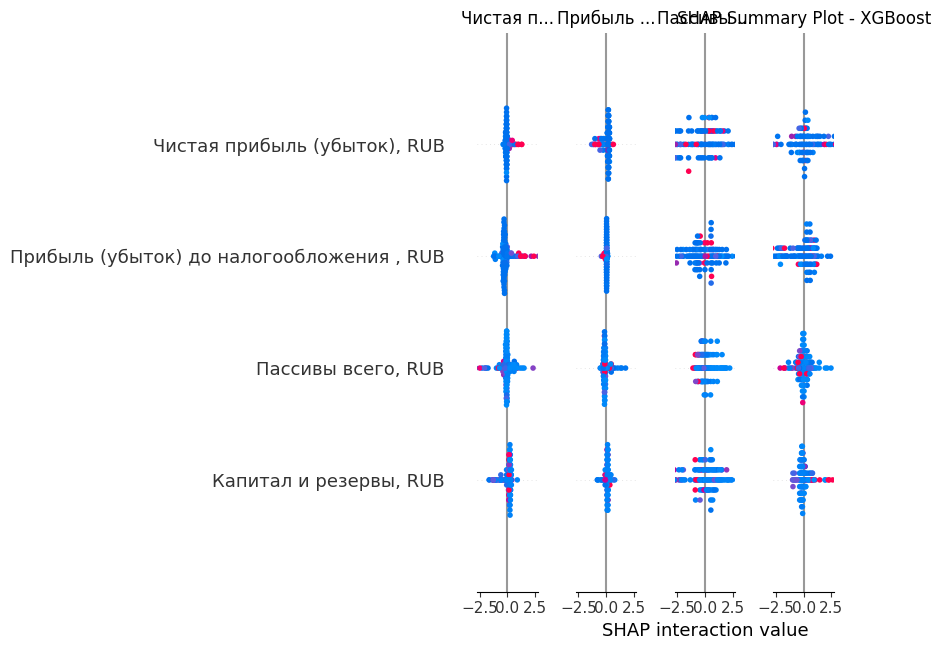

✅ SHAP анализ выполнен успешно

4. ВАЖНОСТЬ ПРИЗНАКОВ
Топ-10 самых важных признаков:
   1. Капитал и резервы, RUB: 0.1336
   7. Прибыль (убыток) от продажи, RUB: 0.1316
   8. Регион_код: 0.1121
   3. Чистая прибыль (убыток), RUB: 0.1113
   4. Прибыль (убыток) до налогообложения , RUB: 0.1112
   2. Пассивы всего, RUB: 0.1095
   5. Остаток средств на конец отчетного года, RUB: 0.1050
   6. Прочие расходы, RUB: 0.1023
   9. ОПФ_код: 0.0836


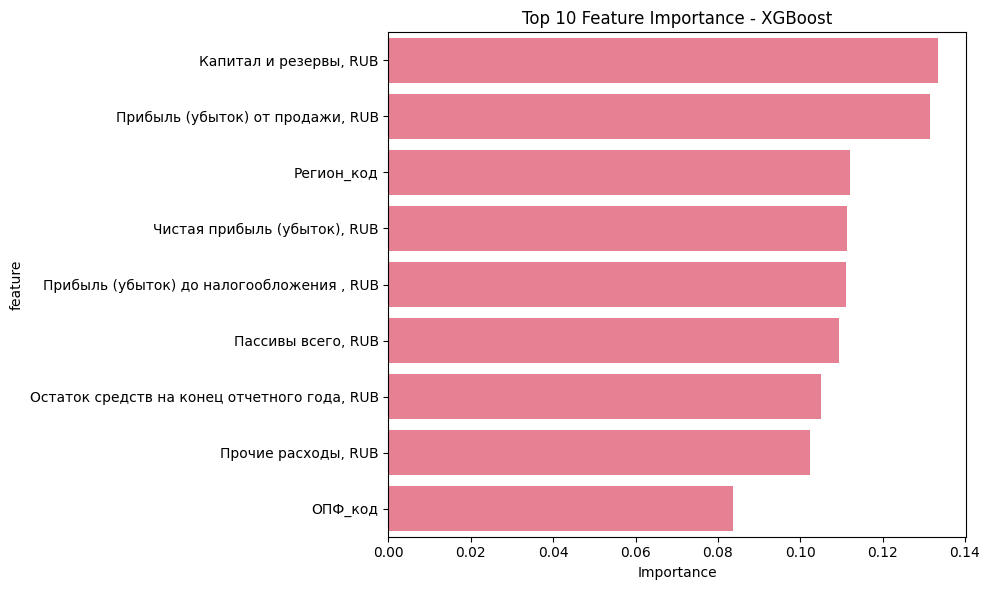


5. МАТРИЦА ОШИБОК


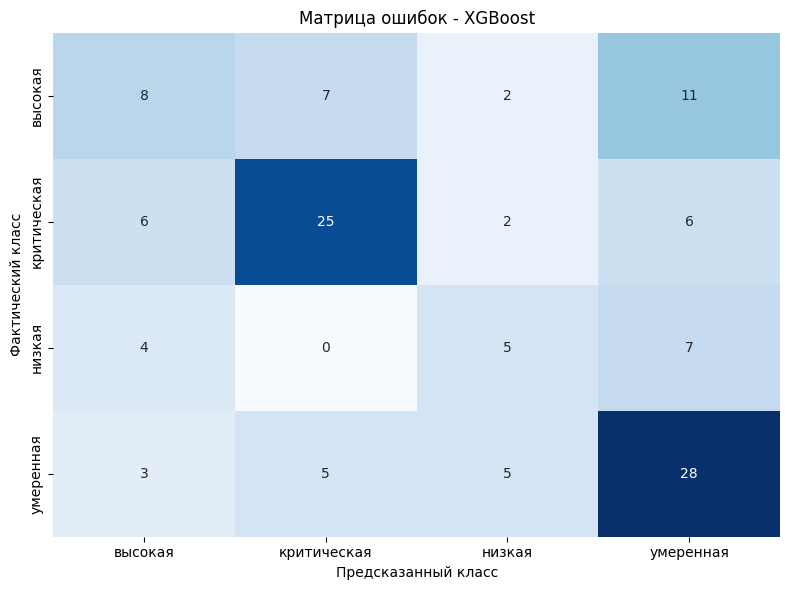


6. ПРИМЕРЫ ПРЕДСКАЗАНИЙ
Примеры предсказаний:

Пример 1:
  Фактический: умеренная
  Предсказанный: умеренная
  Вероятность: 0.796
  Правильно: ✅

Пример 2:
  Фактический: критическая
  Предсказанный: критическая
  Вероятность: 0.983
  Правильно: ✅

Пример 3:
  Фактический: критическая
  Предсказанный: критическая
  Вероятность: 0.965
  Правильно: ✅

Пример 4:
  Фактический: низкая
  Предсказанный: умеренная
  Вероятность: 0.790
  Правильно: ❌

Пример 5:
  Фактический: высокая
  Предсказанный: критическая
  Вероятность: 0.941
  Правильно: ❌

АНАЛИЗ РЕЗУЛЬТАТОВ
XGBoost Accuracy: 0.532
LightGBM Accuracy: 0.516
Лучшая модель: XGBoost

Анализ по классам:
  высокая: 0.286 (n=28)
  критическая: 0.641 (n=39)
  низкая: 0.312 (n=16)
  умеренная: 0.683 (n=41)

🎯 Модель готова к использованию!
   Используйте predict_credit_level(new_data) для предсказаний

СРАВНЕНИЕ С BASELINE
Baseline accuracy (most frequent class): 0.331
Улучшение над baseline: 0.202

✅ Анализ завершен! Качество модели: 0.532


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import lightgbm as lgb
import shap

df = pd.read_csv('data/merged_data10_with_coeff_and_levels.csv', low_memory=False)

print("=== ГРАДИЕНТ БУСТИНГ ДЛЯ ПРЕДСКАЗАНИЯ УРОВНЯ ЗАКРЕДИТОВАННОСТИ ===\n")

# Подготовка данных
def prepare_gb_data(df):
    """Подготовка данных для градиент бустинга"""
    
    # Значимые факторы из предыдущего анализа
    features = [
        'Капитал и резервы, RUB',
        'Пассивы всего, RUB', 
        'Чистая прибыль (убыток), RUB',
        'Прибыль (убыток) до налогообложения , RUB',
        'Остаток средств на конец отчетного года, RUB',
        'Прочие расходы, RUB',
        'Прибыль (убыток) от продажи, RUB',
        'Регион регистрации',
        'Организационно-правовая форма'
    ]
    
    # Проверяем доступные признаки
    available_features = [f for f in features if f in df.columns]
    print(f"Используем {len(available_features)} признаков из {len(features)}")
    
    # Создаем датасет
    ml_df = df[available_features + ['Уровень_закредитованности']].copy()
    
    # Кодируем категориальные переменные
    le = LabelEncoder()
    if 'Регион регистрации' in ml_df.columns:
        ml_df['Регион_код'] = le.fit_transform(ml_df['Регион регистрации'].fillna('Unknown'))
        ml_df = ml_df.drop('Регион регистрации', axis=1)
    
    if 'Организационно-правовая форма' in ml_df.columns:
        ml_df['ОПФ_код'] = le.fit_transform(ml_df['Организационно-правовая форма'].fillna('Unknown'))
        ml_df = ml_df.drop('Организационно-правовая форма', axis=1)
    
    # Убираем пропуски в целевой переменной
    ml_df = ml_df.dropna(subset=['Уровень_закредитованности'])
    
    print(f"Итоговый размер данных: {ml_df.shape}")
    print(f"Распределение целевой переменной:")
    print(ml_df['Уровень_закредитованности'].value_counts().sort_index())
    
    return ml_df

# Подготавливаем данные
ml_data = prepare_gb_data(df)
X = ml_data.drop('Уровень_закредитованности', axis=1)
y = ml_data['Уровень_закредитованности']

# Кодируем целевую переменную
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nКодировка целевой переменной:")
for i, class_name in enumerate(le_target.classes_):
    print(f"  {i}: {class_name}")

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nРазделение данных:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

# Заполняем пропуски и масштабируем
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Сохраняем имена признаков для SHAP
feature_names = X.columns.tolist()

# 1. XGBoost
print("\n" + "="*50)
print("1. XGBOOST МОДЕЛЬ")
print("="*50)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)

print("Результаты XGBoost:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))

# 2. LightGBM
print("\n" + "="*50)
print("2. LIGHTGBM МОДЕЛЬ")
print("="*50)

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1  # Отключаем вывод
)

lgb_model.fit(X_train_scaled, y_train)

y_pred_lgb = lgb_model.predict(X_test_scaled)

print("Результаты LightGBM:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb, target_names=le_target.classes_))

# 3. SHAP Анализ для XGBoost (исправленная версия)
print("\n" + "="*50)
print("3. SHAP АНАЛИЗ")
print("="*50)

try:
    # Создаем explainer с правильными параметрами
    explainer = shap.TreeExplainer(
        xgb_model, 
        X_train_scaled,
        feature_perturbation="interventional"
    )
    
    # Вычисляем SHAP значения
    shap_values = explainer.shap_values(X_test_scaled)
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    
    if isinstance(shap_values, list):
        # Многоклассовая классификация
        shap.summary_plot(shap_values, X_test_scaled, 
                         feature_names=feature_names,
                         class_names=le_target.classes_.tolist(), 
                         show=False)
    else:
        # Бинарная или другая структура
        shap.summary_plot(shap_values, X_test_scaled, 
                         feature_names=feature_names, 
                         show=False)
    
    plt.title('SHAP Summary Plot - XGBoost')
    plt.tight_layout()
    plt.show()
    
    print("✅ SHAP анализ выполнен успешно")
    
except Exception as e:
    print(f"❌ Ошибка в SHAP анализе: {e}")
    print("Пробуем альтернативный подход...")
    
    try:
        # Альтернативный подход
        explainer_simple = shap.TreeExplainer(xgb_model)
        shap_values_simple = explainer_simple(X_test_scaled)
        
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values_simple, X_test_scaled, feature_names=feature_names, show=False)
        plt.title('SHAP Summary Plot - XGBoost (Alternative)')
        plt.tight_layout()
        plt.show()
        print("✅ SHAP анализ выполнен альтернативным методом")
        
    except Exception as e2:
        print(f"❌ Ошибка в альтернативном SHAP анализе: {e2}")

# 4. Важность признаков
print("\n" + "="*50)
print("4. ВАЖНОСТЬ ПРИЗНАКОВ")
print("="*50)

# Важность признаков из XGBoost
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Топ-10 самых важных признаков:")
for i, row in importance_df.head(10).iterrows():
    print(f"  {i+1:2d}. {row['feature']}: {row['importance']:.4f}")

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), y='feature', x='importance')
plt.title('Top 10 Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 5. Матрица ошибок
print("\n" + "="*50)
print("5. МАТРИЦА ОШИБОК")
print("="*50)

cm = confusion_matrix(y_test, y_pred_xgb)
cm_df = pd.DataFrame(cm, 
                     index=le_target.classes_, 
                     columns=le_target.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Матрица ошибок - XGBoost')
plt.ylabel('Фактический класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

# 6. Примеры предсказаний
print("\n" + "="*50)
print("6. ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("="*50)

# Берем 5 примеров из тестовой выборки
sample_indices = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)

print("Примеры предсказаний:")
for i, idx in enumerate(sample_indices):
    actual_class = le_target.inverse_transform([y_test[idx]])[0]
    predicted_class = le_target.inverse_transform([y_pred_xgb[idx]])[0]
    probability = max(y_pred_proba_xgb[idx])
    
    print(f"\nПример {i+1}:")
    print(f"  Фактический: {actual_class}")
    print(f"  Предсказанный: {predicted_class}")
    print(f"  Вероятность: {probability:.3f}")
    print(f"  Правильно: {'✅' if actual_class == predicted_class else '❌'}")

# Анализ результатов
print("\n" + "="*50)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*50)

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"LightGBM Accuracy: {accuracy_score(y_test, y_pred_lgb):.3f}")

best_model = xgb_model if accuracy_score(y_test, y_pred_xgb) >= accuracy_score(y_test, y_pred_lgb) else lgb_model
best_model_name = "XGBoost" if accuracy_score(y_test, y_pred_xgb) >= accuracy_score(y_test, y_pred_lgb) else "LightGBM"

print(f"Лучшая модель: {best_model_name}")

# Анализ по классам
print("\nАнализ по классам:")
for i, class_name in enumerate(le_target.classes_):
    class_mask = y_test == i
    if sum(class_mask) > 0:
        class_accuracy = accuracy_score(y_test[class_mask], y_pred_xgb[class_mask])
        print(f"  {class_name}: {class_accuracy:.3f} (n={sum(class_mask)})")

# Функция для предсказания на новых данных
def predict_credit_level(new_data, model=xgb_model, scaler=scaler, imputer=imputer, le_target=le_target, feature_names=feature_names):
    """
    Функция для предсказания уровня закредитованности на новых данных
    """
    # Проверяем и выравниваем признаки
    if isinstance(new_data, pd.DataFrame):
        # Убеждаемся, что порядок признаков правильный
        new_data = new_data[feature_names]
    
    # Предобработка
    new_data_imputed = imputer.transform(new_data)
    new_data_scaled = scaler.transform(new_data_imputed)
    
    # Предсказание
    predictions = model.predict(new_data_scaled)
    probabilities = model.predict_proba(new_data_scaled)
    
    # Декодирование
    predicted_classes = le_target.inverse_transform(predictions)
    
    results = []
    for i, (pred_class, proba) in enumerate(zip(predicted_classes, probabilities)):
        confidence = max(proba)
        results.append({
            'sample': i+1,
            'predicted_level': pred_class,
            'confidence': confidence,
            'all_probabilities': dict(zip(le_target.classes_, proba))
        })
    
    return results

print(f"\n🎯 Модель готова к использованию!")
print(f"   Используйте predict_credit_level(new_data) для предсказаний")

# Дополнительный анализ: сравнение с baseline
print("\n" + "="*50)
print("СРАВНЕНИЕ С BASELINE")
print("="*50)

# Baseline - предсказываем самый частый класс
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_scaled, y_train)
y_pred_dummy = dummy_clf.predict(X_test_scaled)
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)

print(f"Baseline accuracy (most frequent class): {dummy_accuracy:.3f}")
print(f"Улучшение над baseline: {accuracy_score(y_test, y_pred_xgb) - dummy_accuracy:.3f}")

print(f"\n✅ Анализ завершен! Качество модели: {accuracy_score(y_test, y_pred_xgb):.3f}")

In [ ]:
# дополнительно применим инструменты ML:
# Мы использовали градиентный бустинг (XGBoost и LightGBM) для предсказания уровня закредитованности компаний.
# Что получилось:
# Модель предсказывает правильно в 53% случаев - это лучше, чем простое угадывание (33%), но недостаточно для полного автоматического принятия решений
# Лучше всего модель определяет компании с "критической" (64% точности) и "умеренной" (68% точности) закредитованностью
# Хуже распознает "высокую" и "низкую" закредитованность - видимо, эти состояния сложнее отличить по финансовым показателям
# Самые важные факторы для предсказания:
# Размер капитала и резервов компании
# Прибыль от основной деятельности
# Регион, где работает компания
# Практический смысл:
# Такую модель можно использовать как "систему раннего предупреждения" - она помогает выявить потенциально проблемные компании, но окончательное решение должно приниматься с участием финансовых экспертов. Особенно полезна модель для быстрого отсеивания компаний с критическим уровнем долговой нагрузки.